# Лабораторная работа: Семантическая сегментация (U-Net)

**Дисциплина:** Распознавание образов и индуктивное моделирование (РОИМ)
**Тема:** Свёрточные сети, попиксельная классификация, архитектура U-Net.

## Цель работы
Реализовать с нуля архитектуру **U-Net** и обучить её решать задачу **семантической сегментации** на синтетических данных (кружки на шумном фоне).

## Что нужно сделать
1. Изучить готовый синтетический датасет и визуализацию.
2. Реализовать строительные блоки U-Net (`DoubleConv`, `Down`, `Up`).
3. Собрать полную модель `UNet`.
4. Реализовать функцию потерь **Dice loss** и метрику **IoU**.
5. Обучить модель и визуализировать предсказания.
6. Сравнить BCE-loss и Dice-loss.
7. Сделать выводы.

---
## Теоретический контекст

**Семантическая сегментация** — это задача классификации **каждого пикселя** входного изображения. Выход модели имеет ту же пространственную размерность, что и вход: $H \times W \times C$, где $C$ — число классов.

В нашем случае задача бинарная ($C = 1$): нужно отделить «объект» от «фона».

### Архитектура U-Net (Ronneberger et al., 2015)

U-Net — свёрточная сеть в виде буквы **U**:
- **Энкодер** (contracting path) — последовательность `Conv → Pool`, уменьшает пространственное разрешение, увеличивает число каналов.
- **Декодер** (expansive path) — последовательность `Upsample → Conv`, восстанавливает разрешение.
- **Skip-connections** — на каждом уровне декодера к признакам конкатенируются признаки соответствующего уровня энкодера. Это позволяет восстановить **точные границы** объектов.

Базовый блок — `DoubleConv`: `Conv3×3 → BN → ReLU → Conv3×3 → BN → ReLU`.

### Функции потерь и метрика

**Binary Cross-Entropy:**
$$
\mathcal{L}_{BCE} = -\frac{1}{N} \sum_i \big[ y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \big].
$$

**Dice loss** (хорошо работает при сильной несбалансированности классов):
$$
\text{Dice} = \frac{2 \sum_i y_i \hat{y}_i + \varepsilon}{\sum_i y_i + \sum_i \hat{y}_i + \varepsilon},
\qquad
\mathcal{L}_{Dice} = 1 - \text{Dice}.
$$

**IoU (Intersection over Union)** — основная метрика сегментации:
$$
\text{IoU} = \frac{|Y \cap \hat{Y}|}{|Y \cup \hat{Y}|}
       = \frac{\sum_i y_i \hat{y}_i}{\sum_i (y_i + \hat{y}_i - y_i \hat{y}_i)}.
$$


In [1]:
import math
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


def set_seed(seed=42):
    """Фиксируем seed для воспроизводимости экспериментов."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 11


Device: cuda


# 1. Синтетический датасет

Чтобы не зависеть от внешних данных, генерируем изображения программно:
- размер $H = W = 64$, один канал (градации серого);
- фон — гауссов шум;
- на каждое изображение помещаем 1–3 круга случайного радиуса и положения;
- маска = $1$ в пикселях круга, $0$ — на фоне.

Датасет уже реализован — его менять не нужно.

In [2]:
IMG_SIZE = 64


def _make_sample(rng):
    img = rng.normal(loc=0.3, scale=0.15, size=(IMG_SIZE, IMG_SIZE)).astype(np.float32)
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    n_objects = rng.integers(1, 4)
    yy, xx = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]

    for _ in range(int(n_objects)):
        cx = rng.integers(8, IMG_SIZE - 8)
        cy = rng.integers(8, IMG_SIZE - 8)
        r = rng.integers(4, 12)
        circle = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        img[circle] = 0.85 + rng.normal(0, 0.05, size=circle.sum())
        mask[circle] = 1.0

    img = np.clip(img, 0.0, 1.0)
    return img, mask


class SyntheticSegDataset(Dataset):
    def __init__(self, n_samples=512, seed=0):
        self.n_samples = n_samples
        self.rng = np.random.default_rng(seed)
        self._cache = [_make_sample(self.rng) for _ in range(n_samples)]

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img, mask = self._cache[idx]
        img_t = torch.from_numpy(img).unsqueeze(0)   # (1, H, W)
        mask_t = torch.from_numpy(mask).unsqueeze(0) # (1, H, W)
        return img_t, mask_t

# 2. Визуализация

Утилита для отображения тройки `(image, mask, prediction)`. Уже готова.

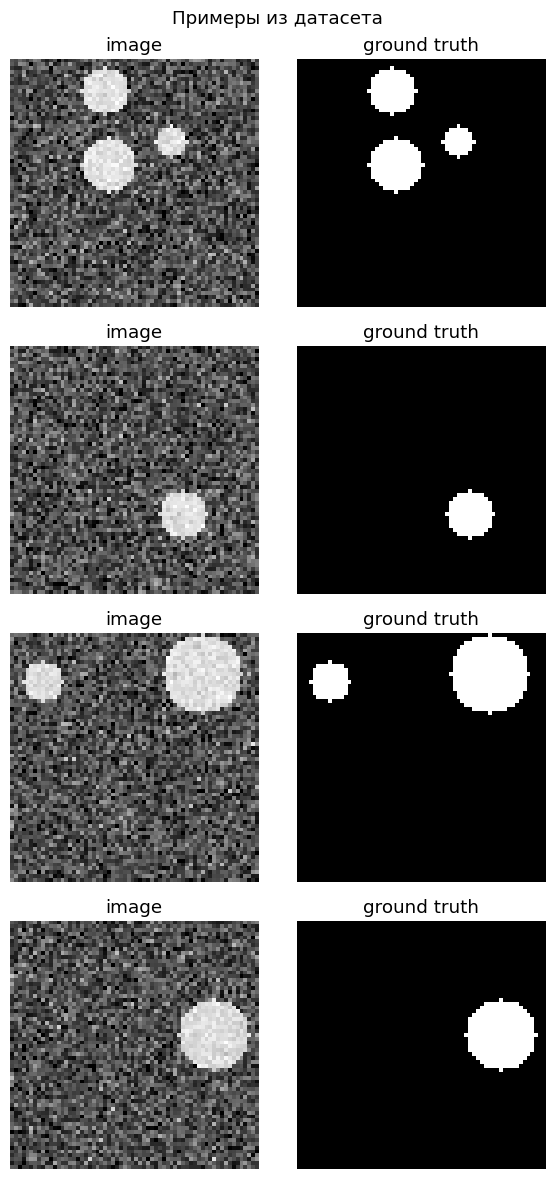

In [3]:
def show_batch(images, masks, preds=None, n=4, threshold=0.5, title=""):
    n = min(n, images.shape[0])
    cols = 3 if preds is not None else 2
    fig, axes = plt.subplots(n, cols, figsize=(3 * cols, 3 * n))
    if n == 1:
        axes = axes[None, :]
    for i in range(n):
        axes[i, 0].imshow(images[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 0].set_title("image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(masks[i, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("ground truth")
        axes[i, 1].axis("off")
        if preds is not None:
            pred_mask = (torch.sigmoid(preds[i, 0]) > threshold).float().cpu().numpy()
            axes[i, 2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
            axes[i, 2].set_title("prediction")
            axes[i, 2].axis("off")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def preview_dataset(ds, n=4):
    imgs = torch.stack([ds[i][0] for i in range(n)])
    masks = torch.stack([ds[i][1] for i in range(n)])
    show_batch(imgs, masks, n=n, title="Примеры из датасета")


train_ds = SyntheticSegDataset(n_samples=512, seed=0)
val_ds = SyntheticSegDataset(n_samples=128, seed=99)
preview_dataset(train_ds)

# 3. Архитектура U-Net

Схема ниже описывает упрощённую U-Net глубины 3 (3 уровня downsampling).

```
вход (1×64×64)
   │
[DoubleConv c=32] ─── skip₁ ────────────┐
   │ MaxPool                            │
[DoubleConv c=64] ─── skip₂ ───────┐    │
   │ MaxPool                       │    │
[DoubleConv c=128] ─── skip₃ ───┐  │    │
   │ MaxPool                    │  │    │
[DoubleConv c=256]  ← bottleneck│  │    │
   │ Upsample + concat(skip₃) ──┘  │    │
[DoubleConv c=128]                 │    │
   │ Upsample + concat(skip₂) ─────┘    │
[DoubleConv c=64]                       │
   │ Upsample + concat(skip₁) ──────────┘
[DoubleConv c=32]
   │
Conv 1×1 → (1×64×64)  ← logits
```

## 3.1 `DoubleConv` — два подряд `Conv-BN-ReLU`

## Задание
Реализуйте блок:
`Conv2d(3×3, padding=1) → BatchNorm2d → ReLU → Conv2d(3×3, padding=1) → BatchNorm2d → ReLU`.

In [4]:
class DoubleConv(nn.Module):
    """Блок Conv(3x3) -> BN -> ReLU -> Conv(3x3) -> BN -> ReLU.

    padding=1 сохраняет высоту и ширину feature map.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

## 3.2 `Down` — шаг энкодера

`MaxPool2d(2) → DoubleConv`. Возвращает признаки после уменьшения разрешения в 2 раза.

In [5]:
class Down(nn.Module):
    """Шаг энкодера: уменьшаем разрешение в 2 раза и увеличиваем число каналов."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        return self.conv(self.pool(x))

## 3.3 `Up` — шаг декодера со skip-connection

`Upsample(scale=2) → concat(skip) → DoubleConv`.

Обратите внимание: после `Upsample` число каналов увеличенного тензора равно `in_channels // 2` (мы апсемплим выход более глубокого уровня), после конкатенации со skip-тензором получается `in_channels` каналов, и `DoubleConv` ужимает их до `out_channels`.

In [6]:
class Up(nn.Module):
    """Шаг декодера: upsample -> concat со skip-connection -> DoubleConv."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        # Для размера 64x64 проблем не будет, но этот код делает блок устойчивым
        # и к нечётным размерам изображений.
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

## 3.4 Полная модель `UNet`

Соберите модель из блоков выше. Используйте число каналов `[32, 64, 128, 256]` (последний — bottleneck).

## Задание
Заполните `__init__` и `forward` (порядок указан в комментариях).

In [7]:
class UNet(nn.Module):
    """Упрощённая U-Net для бинарной сегментации.

    На выходе возвращаются logits размера (B, out_channels, H, W).
    Сигмоиду здесь не применяем: это численно стабильнее делать внутри loss/metric.
    """
    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        self.inc   = DoubleConv(in_channels, base)             # 32
        self.down1 = Down(base,   base * 2)                    # 64
        self.down2 = Down(base*2, base * 4)                    # 128
        self.down3 = Down(base*4, base * 8)                    # 256 (bottleneck)

        # in_channels для Up = каналы upsampled-тензора + каналы skip-тензора
        self.up1   = Up(base * 8 + base * 4, base * 4)         # 256 + 128 -> 128
        self.up2   = Up(base * 4 + base * 2, base * 2)         # 128 + 64  -> 64
        self.up3   = Up(base * 2 + base,     base)             # 64 + 32   -> 32
        self.outc  = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)          # skip 1: (B, base, 64, 64)
        x2 = self.down1(x1)       # skip 2: (B, base*2, 32, 32)
        x3 = self.down2(x2)       # skip 3: (B, base*4, 16, 16)
        x4 = self.down3(x3)       # bottleneck: (B, base*8, 8, 8)

        x = self.up1(x4, x3)
        x = self.up2(x,  x2)
        x = self.up3(x,  x1)
        return self.outc(x)

# 4. Функция потерь Dice

$$
\mathcal{L}_{Dice} = 1 - \frac{2 \sum_i y_i\, \hat{y}_i + \varepsilon}{\sum_i y_i + \sum_i \hat{y}_i + \varepsilon}.
$$

Здесь $\hat{y}_i$ — **сигмоида** от логитов, $y_i$ — таргет, $\varepsilon$ — небольшая константа для стабильности (например, $10^{-6}$).

## Задание
Реализуйте `dice_loss(logits, target)`.

In [8]:
def dice_loss(logits, target, eps=1e-6):
    """Dice loss для бинарной сегментации.

    Считаем Dice отдельно для каждого изображения в батче, затем усредняем.
    """
    probs = torch.sigmoid(logits)
    probs = probs.reshape(probs.shape[0], -1)
    target = target.reshape(target.shape[0], -1)

    intersection = (probs * target).sum(dim=1)
    denominator = probs.sum(dim=1) + target.sum(dim=1)
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()

# 5. Метрика IoU

$$
\text{IoU} = \frac{\sum_i \hat{y}_i\, y_i}{\sum_i (\hat{y}_i + y_i - \hat{y}_i\, y_i)}.
$$

Перед расчётом IoU предсказание бинаризуется по порогу `threshold`.

## Задание
Реализуйте `iou_score(logits, target, threshold=0.5)`.

In [9]:
def iou_score(logits, target, threshold=0.5, eps=1e-6):
    """IoU/Jaccard index для бинарной сегментации.

    Возвращает средний IoU по батчу.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.reshape(preds.shape[0], -1)
    target = target.reshape(target.shape[0], -1)

    intersection = (preds * target).sum(dim=1)
    union = preds.sum(dim=1) + target.sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean()


def count_parameters(model):
    """Число обучаемых параметров модели."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Быстрая проверка размерностей до запуска обучения
_test_model = UNet()
_test_x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    _test_y = _test_model(_test_x)
assert _test_y.shape == (2, 1, IMG_SIZE, IMG_SIZE)
print("UNet output shape:", tuple(_test_y.shape))
print(f"Trainable parameters: {count_parameters(_test_model):,}")
del _test_model, _test_x, _test_y

UNet output shape: (2, 1, 64, 64)
Trainable parameters: 1,947,713


# 6. Обучающий цикл

Стандартный PyTorch-цикл: forward → loss → backward → step. Уже реализован.

In [10]:
def train_unet(model, train_loader, val_loader, loss_fn,
               epochs=10, lr=1e-3, device=DEVICE):
    """Обучение модели и подсчёт validation IoU после каждой эпохи.

    В history дополнительно сохраняется время эпохи — оно пригодится
    для сравнения глубины сети в дополнительном задании.
    """
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_iou": [], "epoch_time": []}

    for epoch in range(epochs):
        start_time = time.perf_counter()
        model.train()
        epoch_loss = 0.0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = loss_fn(logits, masks)

            opt.zero_grad()
            loss.backward()
            opt.step()

            epoch_loss += loss.item() * imgs.size(0)

        epoch_loss /= len(train_loader.dataset)

        model.eval()
        ious = []
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                logits = model(imgs)
                ious.append(iou_score(logits, masks).item())

        val_iou = float(np.mean(ious))
        epoch_time = time.perf_counter() - start_time

        history["train_loss"].append(epoch_loss)
        history["val_iou"].append(val_iou)
        history["epoch_time"].append(epoch_time)
        print(
            f"[epoch {epoch + 1:2d}] loss={epoch_loss:.4f}  "
            f"val_IoU={val_iou:.3f}  time={epoch_time:.1f}s"
        )

    return history


def plot_history(history, title="Кривая обучения"):
    """Показываем loss и IoU на разных осях, потому что масштабы разные."""
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(epochs, history["train_loss"], linewidth=2, label="train loss")
    ax1.set_xlabel("Эпоха")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(epochs, history["val_iou"], linewidth=2, linestyle="--", label="val IoU")
    ax2.set_ylabel("IoU")
    ax2.set_ylim(0, 1.0)

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="center right")
    ax1.set_title(title)
    plt.show()


# 7. Эксперимент 1: обучение U-Net

Обучите модель на сгенерированном датасете и постройте кривую обучения. Параметры по умолчанию: `epochs=10`, `batch_size=32`, `lr=1e-3`, лосс — `BCEWithLogitsLoss`.

## Задание
Раскомментируйте код ниже после реализации модели и метрик.

BCE model parameters: 1,947,713
[epoch  1] loss=0.3790  val_IoU=0.849  time=0.6s
[epoch  2] loss=0.2767  val_IoU=0.954  time=0.3s
[epoch  3] loss=0.2347  val_IoU=0.976  time=0.2s
[epoch  4] loss=0.2001  val_IoU=0.984  time=0.3s
[epoch  5] loss=0.1691  val_IoU=0.991  time=0.2s
[epoch  6] loss=0.1434  val_IoU=0.994  time=0.2s
[epoch  7] loss=0.1220  val_IoU=0.996  time=0.2s
[epoch  8] loss=0.1043  val_IoU=0.995  time=0.3s
[epoch  9] loss=0.0896  val_IoU=0.998  time=0.3s
[epoch 10] loss=0.0772  val_IoU=0.999  time=0.2s
[epoch 11] loss=0.0663  val_IoU=0.999  time=0.3s
[epoch 12] loss=0.0576  val_IoU=0.998  time=0.3s
[epoch 13] loss=0.0504  val_IoU=0.999  time=0.3s
[epoch 14] loss=0.0444  val_IoU=0.997  time=0.2s
[epoch 15] loss=0.0393  val_IoU=0.998  time=0.3s
[epoch 16] loss=0.0350  val_IoU=0.999  time=0.2s
[epoch 17] loss=0.0315  val_IoU=0.999  time=0.3s
[epoch 18] loss=0.0283  val_IoU=0.999  time=0.2s
[epoch 19] loss=0.0256  val_IoU=0.999  time=0.2s
[epoch 20] loss=0.0232  val_IoU=0.999

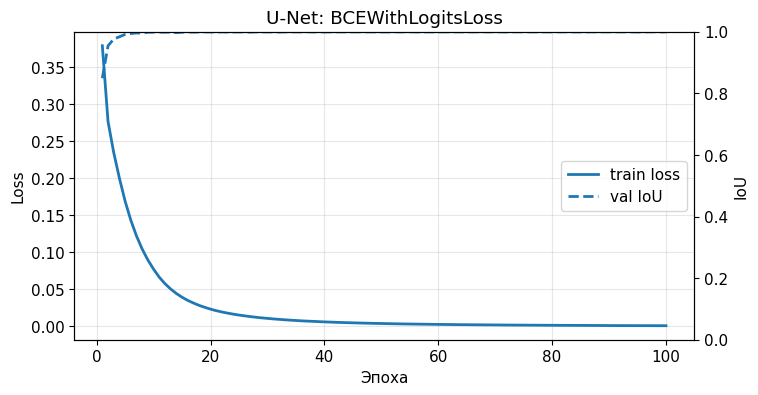

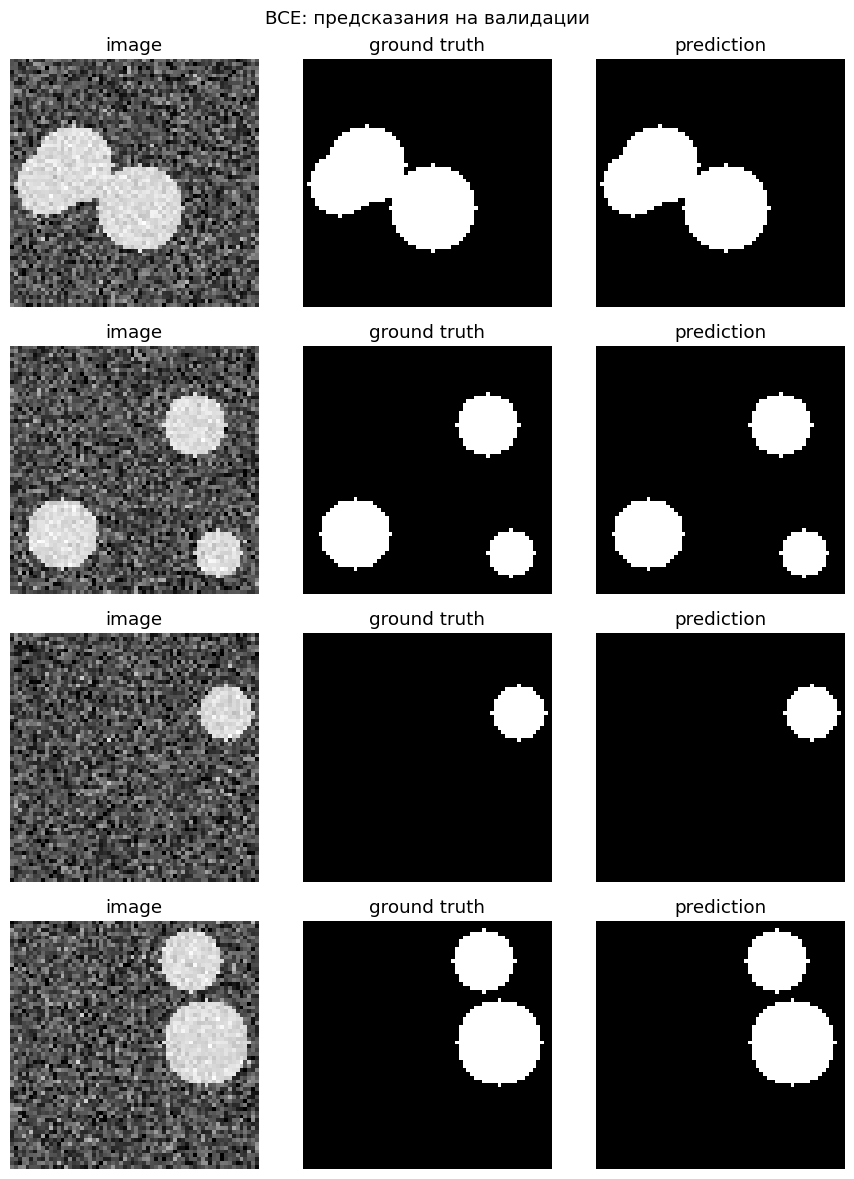

In [11]:
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
MODEL_BASE = 32

# На CPU полный запуск трёх моделей может занять время.
# Финальный прогон: 100 эпох. При нехватке времени можно временно уменьшить EPOCHS или MODEL_BASE.
def make_loaders(batch_size=BATCH_SIZE, seed=42):
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=generator)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


train_loader, val_loader = make_loaders()

set_seed(42)
model_bce = UNet(base=MODEL_BASE).to(DEVICE)
print(f"BCE model parameters: {count_parameters(model_bce):,}")

history_bce = train_unet(
    model_bce,
    train_loader,
    val_loader,
    loss_fn=nn.BCEWithLogitsLoss(),
    epochs=EPOCHS,
    lr=LR,
)

plot_history(history_bce, title="U-Net: BCEWithLogitsLoss")

# Визуализация предсказаний на валидации
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

model_bce.eval()
with torch.no_grad():
    preds = model_bce(imgs)

show_batch(imgs, masks, preds, n=4, title="BCE: предсказания на валидации")

# 8. Эксперимент 2: BCE vs Dice vs BCE + Dice

Обучите ещё две модели:
- с лоссом `dice_loss`,
- с комбинированным лоссом $\mathcal{L} = \text{BCE} + \mathcal{L}_{Dice}$.

Постройте на одном графике кривые `val_IoU` для всех трёх моделей и сравните финальные значения.

## Задание
Раскомментируйте код ниже.

[epoch  1] loss=0.6690  val_IoU=0.921  time=0.3s
[epoch  2] loss=0.5986  val_IoU=0.817  time=0.3s
[epoch  3] loss=0.5539  val_IoU=0.892  time=0.3s
[epoch  4] loss=0.5129  val_IoU=0.903  time=0.3s
[epoch  5] loss=0.4768  val_IoU=0.893  time=0.3s
[epoch  6] loss=0.4379  val_IoU=0.887  time=0.3s
[epoch  7] loss=0.3983  val_IoU=0.996  time=0.3s
[epoch  8] loss=0.3637  val_IoU=0.985  time=0.3s
[epoch  9] loss=0.3254  val_IoU=0.995  time=0.3s
[epoch 10] loss=0.2839  val_IoU=0.998  time=0.3s
[epoch 11] loss=0.2446  val_IoU=0.998  time=0.3s
[epoch 12] loss=0.1974  val_IoU=0.996  time=0.3s
[epoch 13] loss=0.1546  val_IoU=0.998  time=0.3s
[epoch 14] loss=0.1179  val_IoU=0.998  time=0.3s
[epoch 15] loss=0.0880  val_IoU=0.999  time=0.3s
[epoch 16] loss=0.0688  val_IoU=0.999  time=0.3s
[epoch 17] loss=0.0566  val_IoU=0.999  time=0.3s
[epoch 18] loss=0.0473  val_IoU=0.999  time=0.3s
[epoch 19] loss=0.0413  val_IoU=0.999  time=0.3s
[epoch 20] loss=0.0351  val_IoU=1.000  time=0.3s
[epoch 21] loss=0.03

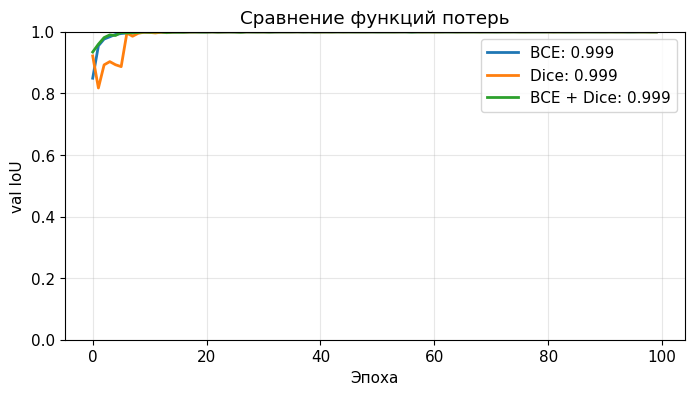

Финальный val_IoU:
  BCE        = 0.999
  Dice       = 0.999
  BCE + Dice = 0.999

Лучший результат в этом запуске: BCE + Dice (val_IoU=0.999).


In [12]:
def combined_loss(logits, target):
    """Комбинированный лосс: BCE отвечает за попиксельную классификацию,
    Dice — за совпадение формы объекта и устойчивость к дисбалансу классов.
    """
    bce = F.binary_cross_entropy_with_logits(logits, target)
    return bce + dice_loss(logits, target)


# Для более честного сравнения используем одинаковый seed и одинаковый порядок батчей.
train_loader, val_loader = make_loaders(seed=42)

set_seed(42)
model_dice = UNet(base=MODEL_BASE).to(DEVICE)
history_dice = train_unet(
    model_dice,
    train_loader,
    val_loader,
    loss_fn=dice_loss,
    epochs=EPOCHS,
    lr=LR,
)

train_loader, val_loader = make_loaders(seed=42)

set_seed(42)
model_comb = UNet(base=MODEL_BASE).to(DEVICE)
history_comb = train_unet(
    model_comb,
    train_loader,
    val_loader,
    loss_fn=combined_loss,
    epochs=EPOCHS,
    lr=LR,
)

plt.figure(figsize=(8, 4))
histories = {
    "BCE": history_bce,
    "Dice": history_dice,
    "BCE + Dice": history_comb,
}

for name, h in histories.items():
    plt.plot(h["val_iou"], linewidth=2, label=f"{name}: {h['val_iou'][-1]:.3f}")

plt.xlabel("Эпоха")
plt.ylabel("val IoU")
plt.ylim(0, 1.0)
plt.title("Сравнение функций потерь")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Финальный val_IoU:")
for name, h in histories.items():
    print(f"  {name:10s} = {h['val_iou'][-1]:.3f}")

best_name = max(histories, key=lambda name: histories[name]["val_iou"][-1])
print(f"\nЛучший результат в этом запуске: {best_name} "
      f"(val_IoU={histories[best_name]['val_iou'][-1]:.3f}).")

# 8.1 Краткие выводы по сравнению лоссов

Ожидаемый результат для этой задачи:

- **BCE** обычно хорошо учится, потому что объекты ярко отделены от фона, но при дисбалансе «фон/объект» может быть менее устойчивой.
- **Dice loss** напрямую оптимизирует перекрытие маски и часто быстрее улучшает IoU, особенно когда объект занимает малую часть изображения.
- **BCE + Dice** часто даёт самый стабильный вариант: BCE помогает пиксельной классификации, а Dice штрафует за плохое совпадение формы объекта.

Точные числа могут немного меняться из-за случайной инициализации, порядка батчей и устройства CPU/GPU, поэтому сравнивать лучше по нескольким запускам или фиксировать seed.

# 8.2 Расширенная визуальная диагностика сегментации

Обычный график `loss / IoU` показывает динамику обучения, но для сегментации часто важнее увидеть **где именно модель ошибается**. Ниже добавлены диагностические ячейки:

- сравнение моделей по IoU / Dice coefficient / precision / recall;
- доля пикселей, которую модель считает объектом;
- лучшие и худшие примеры по IoU;
- probability-map, бинарная маска и error-map.

Для 100 эпох графики специально рисуются без маркеров и со сглаживанием, чтобы не превращаться в «забор».

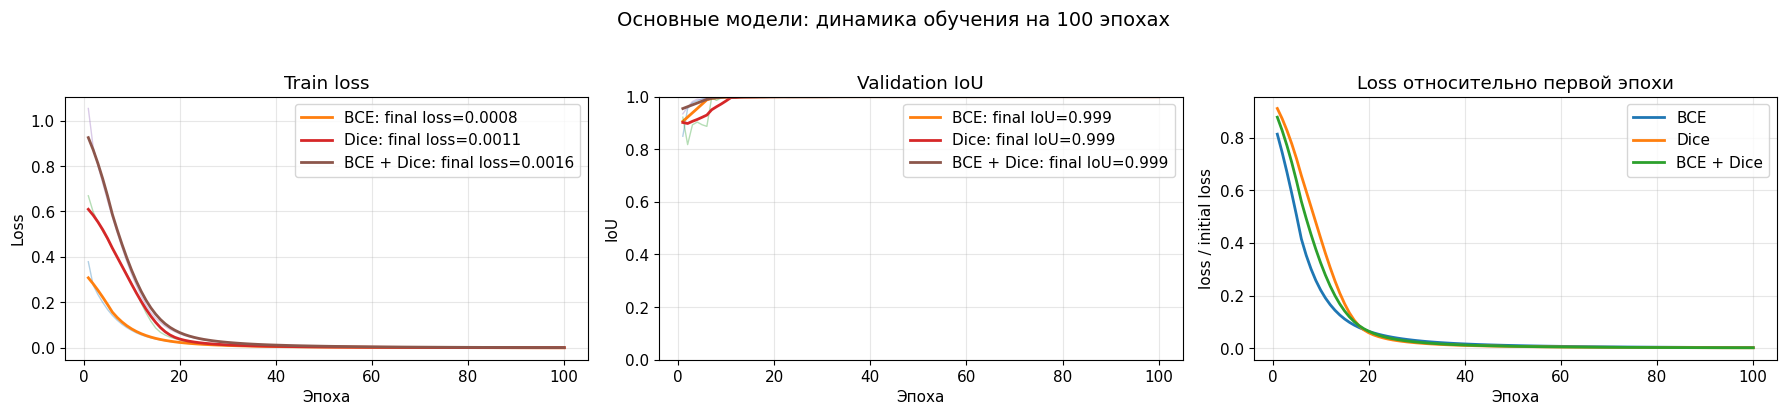

,model,IoU,Dice coefficient,Precision,Recall,Specificity,Predicted object pixels,True object pixels,Mean prob on object,Mean prob on background
0,BCE,0.9994,0.9997,0.9994,1.0000,0.9999,0.0889,0.0889,0.9999,0.0009
1,Dice,0.9994,0.9997,0.9995,0.9999,1.0000,0.0889,0.0889,0.9999,0.0002
2,BCE + Dice,0.9995,0.9997,0.9995,1.0000,0.9999,0.0889,0.0889,0.9999,0.0003


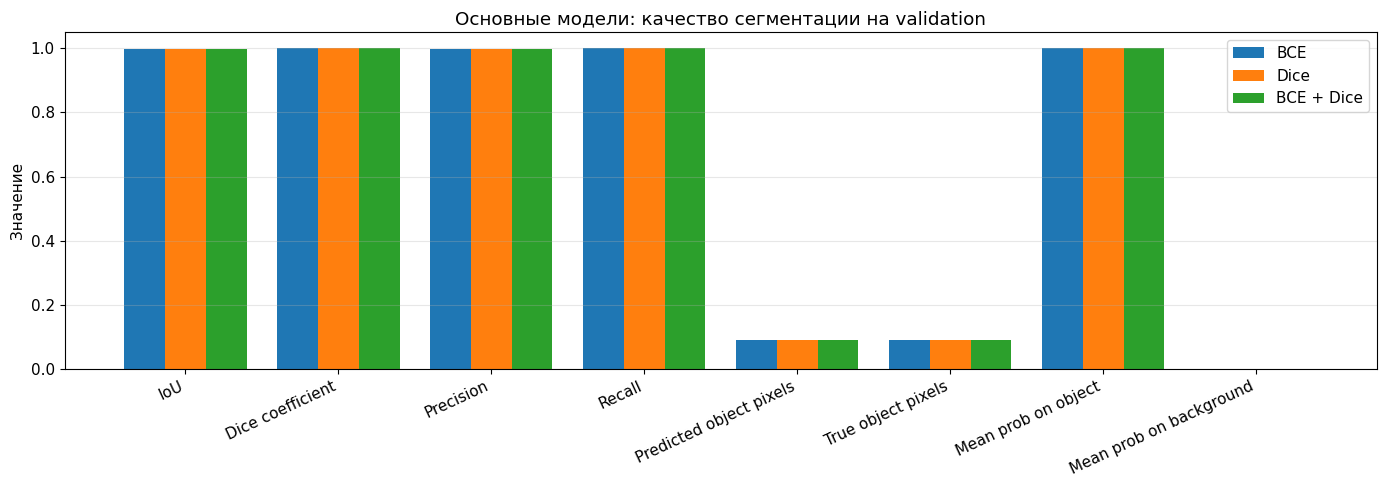

In [13]:
def _moving_average(values, window=7):
    """Сглаживание кривых для длинных запусков на 50-100 эпох."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0 or window <= 1:
        return values
    window = min(int(window), len(values))
    kernel = np.ones(window) / window
    left_pad = window // 2
    right_pad = window - 1 - left_pad
    padded = np.pad(values, (left_pad, right_pad), mode="edge")
    return np.convolve(padded, kernel, mode="valid")


def plot_segmentation_training_dashboard(histories, smooth_window=9, title="Сравнение обучения"):
    """Наглядное сравнение train loss и val IoU для нескольких моделей."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for name, hist in histories.items():
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        loss = np.asarray(hist["train_loss"], dtype=float)
        iou = np.asarray(hist["val_iou"], dtype=float)

        axes[0].plot(epochs, loss, alpha=0.35, linewidth=1)
        axes[0].plot(
            epochs,
            _moving_average(loss, smooth_window),
            linewidth=2,
            label=f"{name}: final loss={loss[-1]:.4f}",
        )

        axes[1].plot(epochs, iou, alpha=0.35, linewidth=1)
        axes[1].plot(
            epochs,
            _moving_average(iou, smooth_window),
            linewidth=2,
            label=f"{name}: final IoU={iou[-1]:.3f}",
        )

        norm_loss = loss / max(loss[0], 1e-8)
        axes[2].plot(
            epochs,
            _moving_average(norm_loss, smooth_window),
            linewidth=2,
            label=name,
        )

    axes[0].set_title("Train loss")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Validation IoU")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("IoU")
    axes[1].set_ylim(0, 1.0)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    axes[2].set_title("Loss относительно первой эпохи")
    axes[2].set_xlabel("Эпоха")
    axes[2].set_ylabel("loss / initial loss")
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    fig.suptitle(title, y=1.03, fontsize=14)
    fig.tight_layout()
    plt.show()


@torch.no_grad()
def evaluate_binary_segmentation_model(model, loader, threshold=0.5, device=DEVICE, max_batches=None):
    """Считает понятные метрики бинарной сегментации на валидации."""
    model.eval()
    model.to(device)

    total_tp = total_fp = total_fn = total_tn = 0.0
    total_pred_pixels = 0.0
    total_true_pixels = 0.0
    total_pixels = 0.0
    prob_on_object = []
    prob_on_background = []

    for batch_idx, (images, masks) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        masks = masks.to(device).float()
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        tp = (preds * masks).sum().item()
        fp = (preds * (1.0 - masks)).sum().item()
        fn = ((1.0 - preds) * masks).sum().item()
        tn = ((1.0 - preds) * (1.0 - masks)).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn
        total_pred_pixels += preds.sum().item()
        total_true_pixels += masks.sum().item()
        total_pixels += masks.numel()

        if masks.sum() > 0:
            prob_on_object.append(probs[masks.bool()].mean().item())
        bg = ~masks.bool()
        if bg.sum() > 0:
            prob_on_background.append(probs[bg].mean().item())

    eps = 1e-8
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    dice = (2.0 * total_tp) / (2.0 * total_tp + total_fp + total_fn + eps)
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    specificity = total_tn / (total_tn + total_fp + eps)

    return {
        "IoU": iou,
        "Dice coefficient": dice,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "Predicted object pixels": total_pred_pixels / (total_pixels + eps),
        "True object pixels": total_true_pixels / (total_pixels + eps),
        "Mean prob on object": float(np.mean(prob_on_object)) if prob_on_object else 0.0,
        "Mean prob on background": float(np.mean(prob_on_background)) if prob_on_background else 0.0,
    }


def evaluate_binary_models(models, loader, threshold=0.5, device=DEVICE, max_batches=None):
    rows = []
    for name, model in models.items():
        metrics = evaluate_binary_segmentation_model(
            model,
            loader,
            threshold=threshold,
            device=device,
            max_batches=max_batches,
        )
        rows.append({"model": name, **metrics})

    try:
        import pandas as pd
        df = pd.DataFrame(rows)
        numeric_cols = [col for col in df.columns if col != "model"]
        df[numeric_cols] = df[numeric_cols].round(4)
        display(df)
        return df
    except Exception:
        for row in rows:
            print(row["model"])
            for key, value in row.items():
                if key != "model":
                    print(f"  {key:26s}: {value:.4f}")
        return rows


def plot_binary_model_metrics(metrics_table, title="Метрики сегментации", exclude_background_metric=False):
    """Barplot по главным метрикам. Работает и с pandas.DataFrame, и со списком словарей."""
    try:
        rows = metrics_table.to_dict("records")
    except AttributeError:
        rows = metrics_table

    metric_names = [
        "IoU",
        "Dice coefficient",
        "Precision",
        "Recall",
        "Predicted object pixels",
        "True object pixels",
    ]
    if not exclude_background_metric:
        metric_names += ["Mean prob on object", "Mean prob on background"]

    x = np.arange(len(metric_names))
    width = 0.8 / max(1, len(rows))

    plt.figure(figsize=(14, 5))
    for idx, row in enumerate(rows):
        offset = (idx - (len(rows) - 1) / 2) * width
        values = [row[m] for m in metric_names]
        plt.bar(x + offset, values, width=width, label=row["model"])

    plt.xticks(x, metric_names, rotation=25, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("Значение")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


main_binary_models = {
    "BCE": model_bce,
    "Dice": model_dice,
    "BCE + Dice": model_comb,
}

plot_segmentation_training_dashboard(
    histories,
    smooth_window=9,
    title="Основные модели: динамика обучения на 100 эпохах",
)

main_metrics = evaluate_binary_models(
    main_binary_models,
    val_loader,
    threshold=0.5,
)

plot_binary_model_metrics(
    main_metrics,
    title="Основные модели: качество сегментации на validation",
)


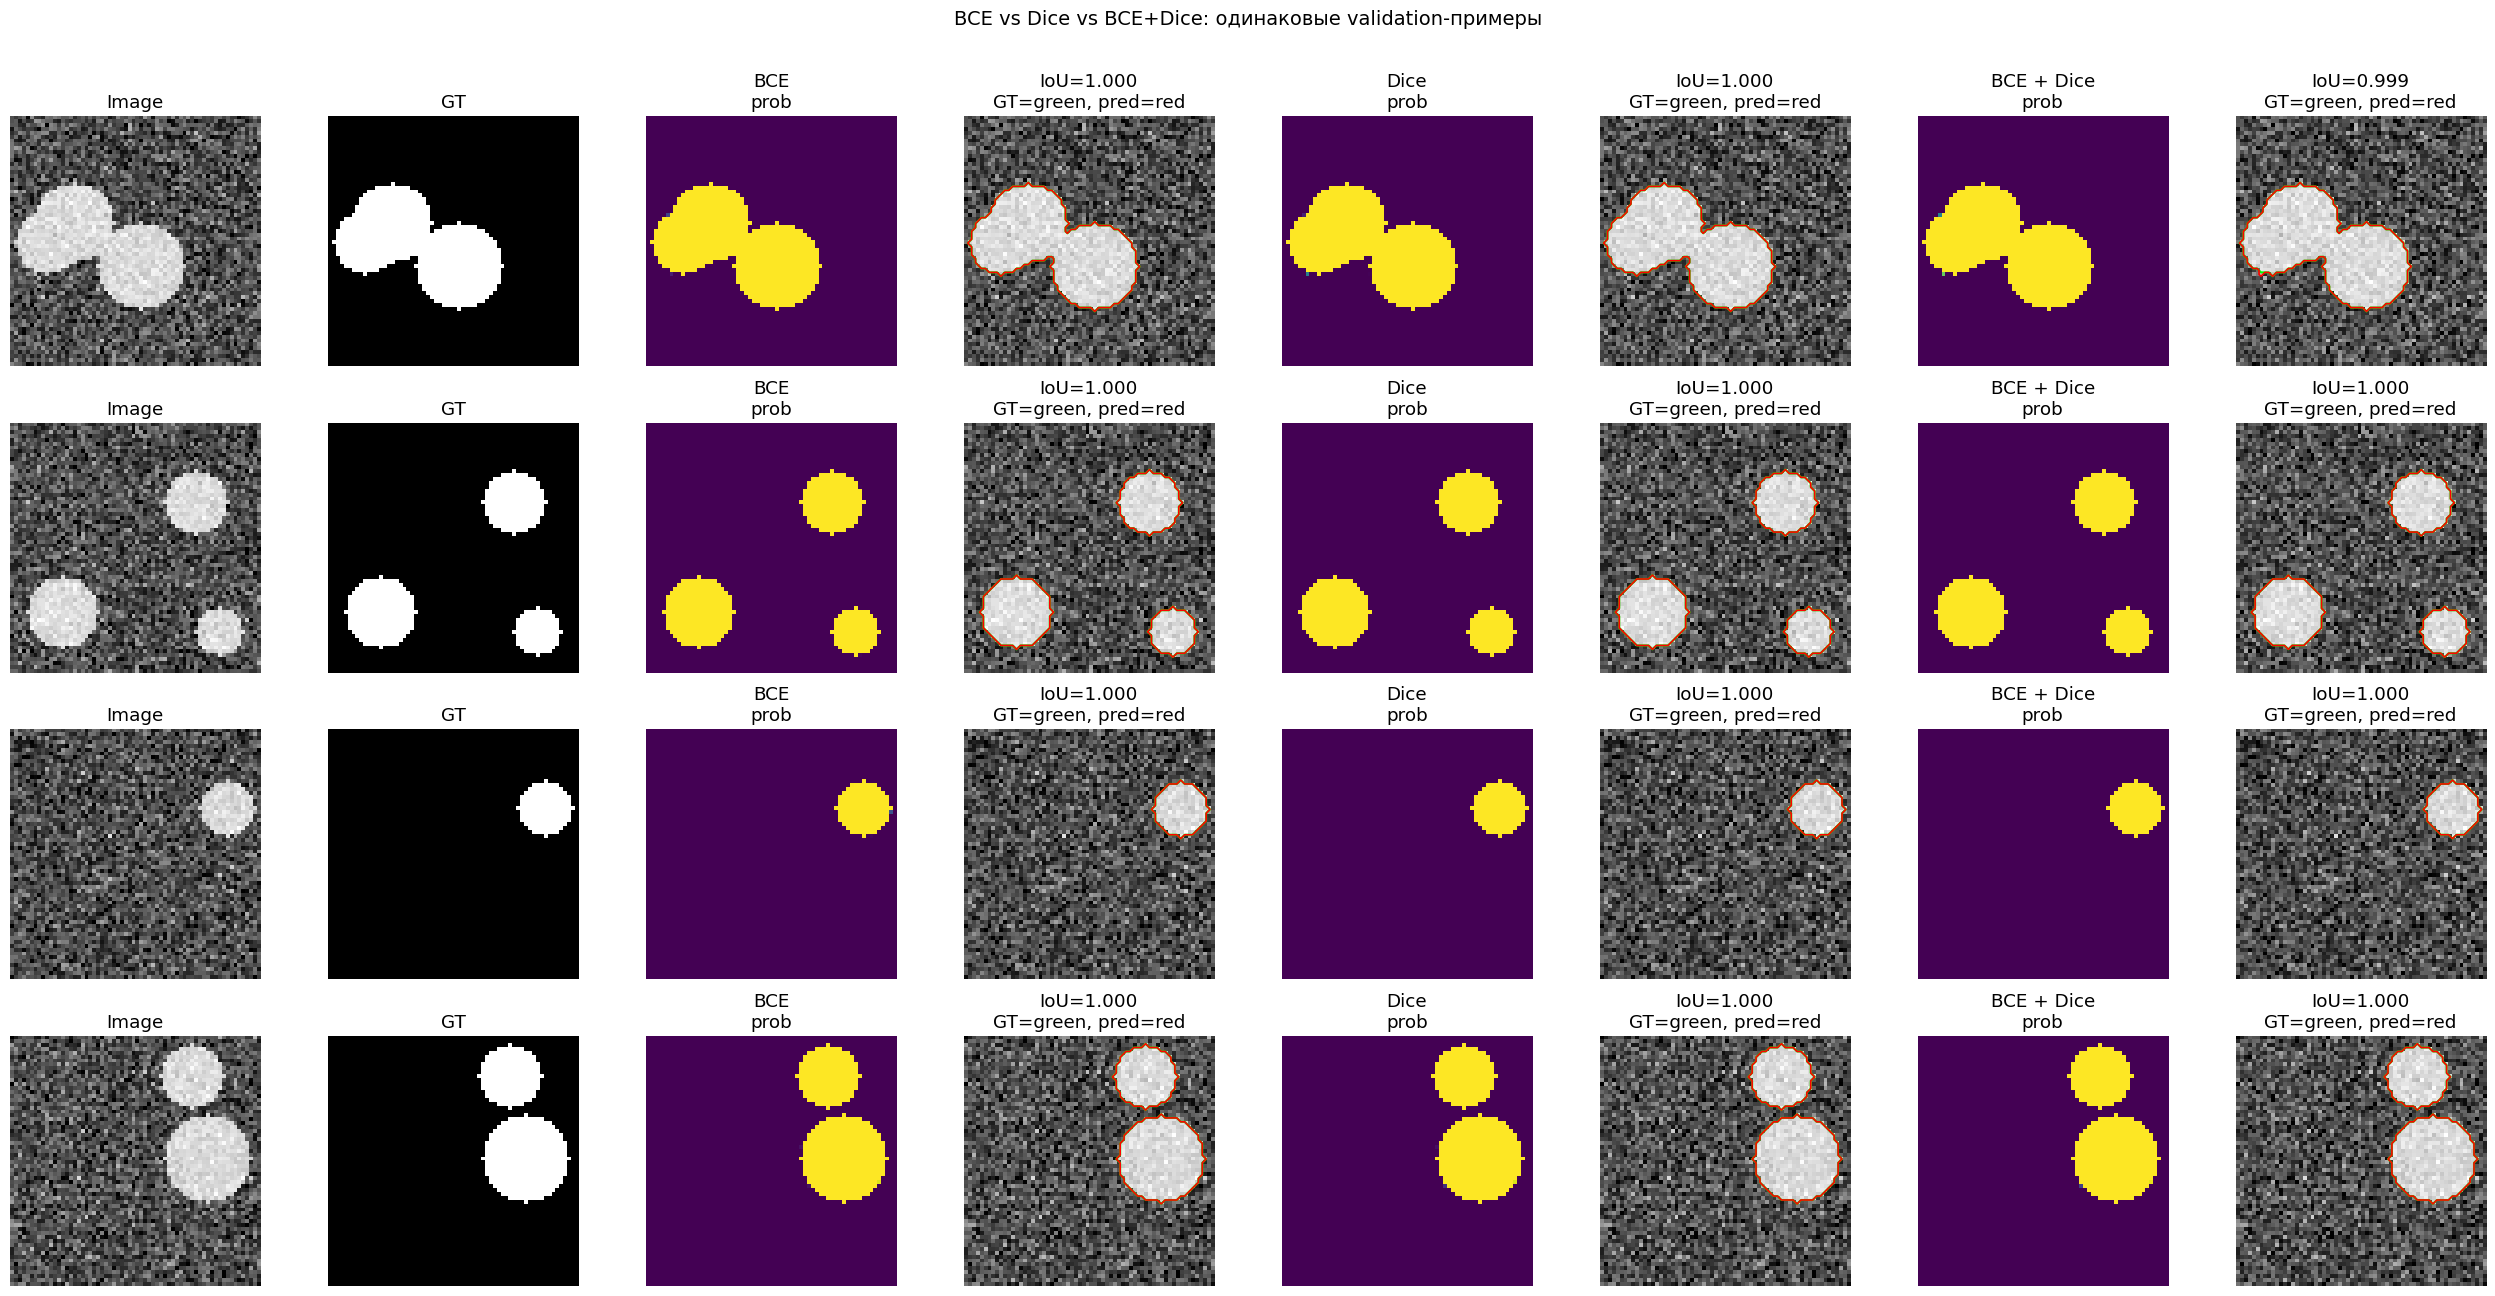

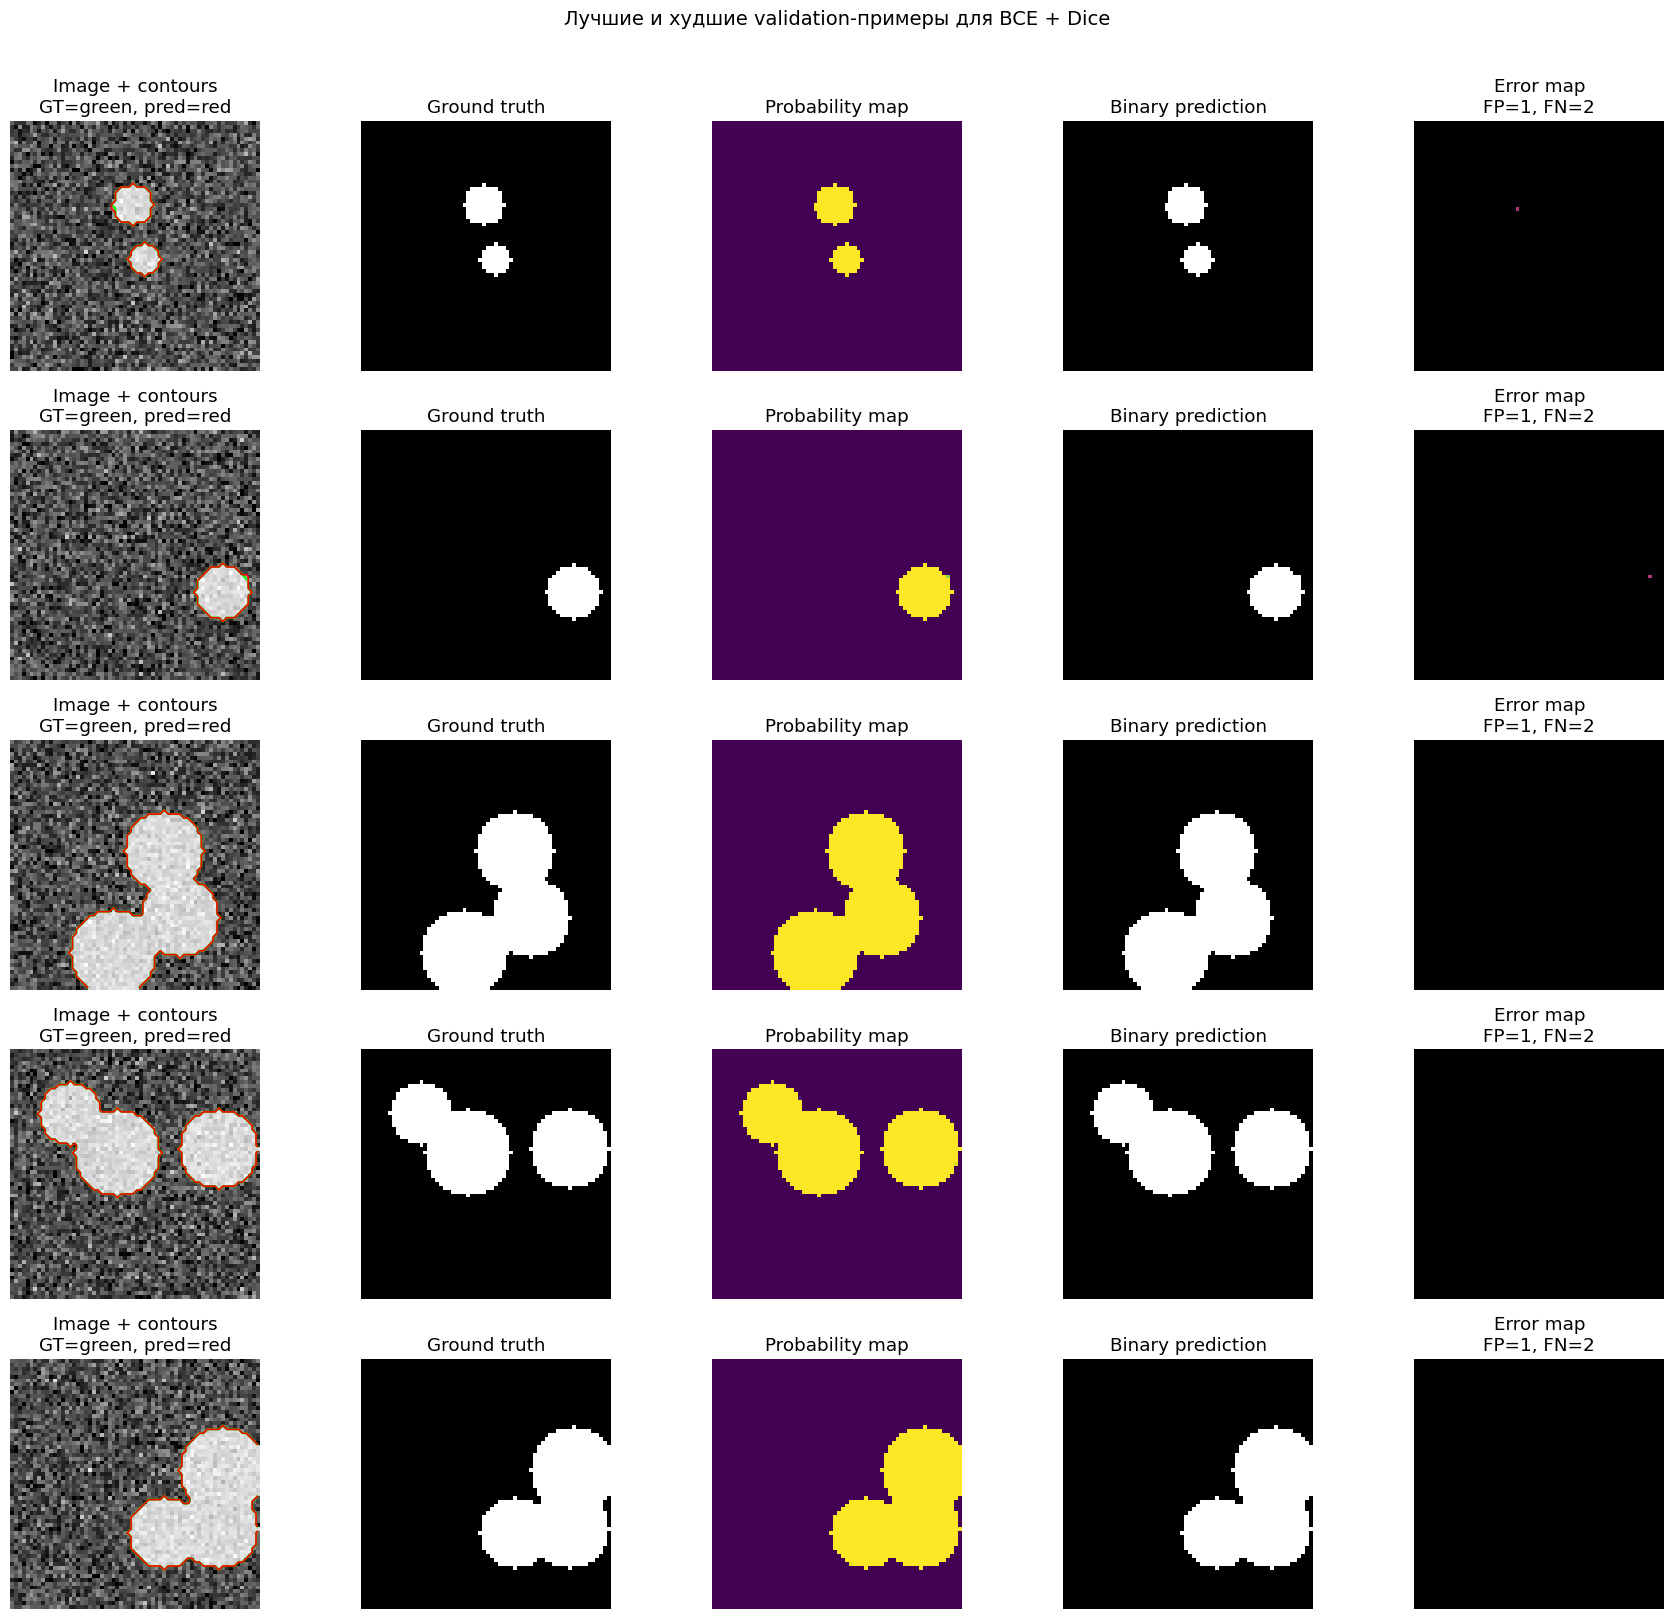

In [14]:
def _binary_metrics_np(pred_mask, true_mask, eps=1e-8):
    pred = pred_mask.astype(bool)
    true = true_mask.astype(bool)
    tp = np.logical_and(pred, true).sum()
    fp = np.logical_and(pred, ~true).sum()
    fn = np.logical_and(~pred, true).sum()
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return {
        "iou": float(iou),
        "dice": float(dice),
        "precision": float(precision),
        "recall": float(recall),
        "pred_frac": float(pred.mean()),
        "true_frac": float(true.mean()),
    }


@torch.no_grad()
def collect_segmentation_predictions(model, loader, threshold=0.5, device=DEVICE, max_batches=4):
    """Собирает примеры с probability-map, бинарной маской и per-image метриками."""
    model.eval()
    model.to(device)
    samples = []

    for batch_idx, (images, masks) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        masks = masks.to(device).float()
        probs = torch.sigmoid(model(images))
        preds = (probs >= threshold).float()

        for i in range(images.size(0)):
            image_np = images[i, 0].detach().cpu().numpy()
            true_np = masks[i, 0].detach().cpu().numpy()
            prob_np = probs[i, 0].detach().cpu().numpy()
            pred_np = preds[i, 0].detach().cpu().numpy()
            metrics = _binary_metrics_np(pred_np, true_np)
            samples.append({
                "image": image_np,
                "true": true_np,
                "prob": prob_np,
                "pred": pred_np,
                **metrics,
            })

    return samples


def _segmentation_error_map(pred_mask, true_mask):
    """0 — правильно, 1 — FP, 2 — FN. Удобно видеть лишние и пропущенные пиксели."""
    pred = pred_mask.astype(bool)
    true = true_mask.astype(bool)
    error = np.zeros_like(true_mask, dtype=float)
    error[np.logical_and(pred, ~true)] = 1.0  # false positive
    error[np.logical_and(~pred, true)] = 2.0  # false negative
    return error


def show_segmentation_examples(samples, n=5, mode="worst", title="Примеры сегментации"):
    """
    mode='worst' — показывает худшие примеры по IoU,
    mode='best' — лучшие,
    mode='mixed' — часть худших и часть лучших.
    """
    if not samples:
        print("Нет примеров для визуализации")
        return

    if mode == "best":
        chosen = sorted(samples, key=lambda s: s["iou"], reverse=True)[:n]
    elif mode == "mixed":
        half = max(1, n // 2)
        worst = sorted(samples, key=lambda s: s["iou"])[:half]
        best = sorted(samples, key=lambda s: s["iou"], reverse=True)[:n - half]
        chosen = worst + best
    else:
        chosen = sorted(samples, key=lambda s: s["iou"])[:n]

    n = len(chosen)
    fig, axes = plt.subplots(n, 5, figsize=(18, 3.2 * n))
    if n == 1:
        axes = axes[None, :]

    for row, sample in enumerate(chosen):
        image = sample["image"]
        true = sample["true"]
        prob = sample["prob"]
        pred = sample["pred"]
        err = _segmentation_error_map(pred, true)

        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].contour(true, levels=[0.5], colors="lime", linewidths=1.5)
        axes[row, 0].contour(pred, levels=[0.5], colors="red", linewidths=1.2)
        axes[row, 0].set_title("Image + contours\nGT=green, pred=red")

        axes[row, 1].imshow(true, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground truth")

        im = axes[row, 2].imshow(prob, cmap="viridis", vmin=0, vmax=1)
        axes[row, 2].set_title("Probability map")

        axes[row, 3].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[row, 3].set_title("Binary prediction")

        axes[row, 4].imshow(err, cmap="magma", vmin=0, vmax=2)
        axes[row, 4].set_title("Error map\nFP=1, FN=2")

        axes[row, 0].set_ylabel(
            f"IoU={sample['iou']:.3f}\nDice={sample['dice']:.3f}\nP={sample['precision']:.2f}, R={sample['recall']:.2f}",
            rotation=0,
            labelpad=52,
            va="center",
        )

        for col in range(5):
            axes[row, col].axis("off")

    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()
    plt.show()


def show_model_comparison_on_same_images(models, loader, n=4, threshold=0.5, device=DEVICE, title="Сравнение моделей"):
    """Показывает предсказания нескольких моделей на одних и тех же изображениях."""
    model_items = list(models.items())
    images, masks = next(iter(loader))
    images = images.to(device)
    masks = masks.to(device).float()
    n = min(n, images.size(0))

    probs_by_model = {}
    preds_by_model = {}
    for name, model in model_items:
        model.eval()
        model.to(device)
        probs = torch.sigmoid(model(images[:n]))
        probs_by_model[name] = probs.detach().cpu().numpy()
        preds_by_model[name] = (probs >= threshold).float().detach().cpu().numpy()

    images_np = images[:n, 0].detach().cpu().numpy()
    masks_np = masks[:n, 0].detach().cpu().numpy()

    cols = 2 + len(model_items) * 2
    fig, axes = plt.subplots(n, cols, figsize=(3.2 * cols, 3.2 * n))
    if n == 1:
        axes = axes[None, :]

    for i in range(n):
        axes[i, 0].imshow(images_np[i], cmap="gray")
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks_np[i], cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("GT")
        axes[i, 1].axis("off")

        col = 2
        for name, _ in model_items:
            prob = probs_by_model[name][i, 0]
            pred = preds_by_model[name][i, 0]
            metrics = _binary_metrics_np(pred, masks_np[i])

            axes[i, col].imshow(prob, cmap="viridis", vmin=0, vmax=1)
            axes[i, col].set_title(f"{name}\nprob")
            axes[i, col].axis("off")

            axes[i, col + 1].imshow(images_np[i], cmap="gray")
            axes[i, col + 1].contour(masks_np[i], levels=[0.5], colors="lime", linewidths=1.5)
            axes[i, col + 1].contour(pred, levels=[0.5], colors="red", linewidths=1.2)
            axes[i, col + 1].set_title(f"IoU={metrics['iou']:.3f}\nGT=green, pred=red")
            axes[i, col + 1].axis("off")

            col += 2

    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()
    plt.show()


# Наглядные примеры для основных моделей.
# Сначала сравниваем все модели на одних и тех же картинках,
# затем отдельно показываем худшие примеры лучшей модели по финальному IoU.
show_model_comparison_on_same_images(
    main_binary_models,
    val_loader,
    n=4,
    threshold=0.5,
    title="BCE vs Dice vs BCE+Dice: одинаковые validation-примеры",
)

best_main_model_name = max(histories, key=lambda name: histories[name]["val_iou"][-1])
best_main_samples = collect_segmentation_predictions(
    main_binary_models[best_main_model_name],
    val_loader,
    threshold=0.5,
    max_batches=4,
)

show_segmentation_examples(
    best_main_samples,
    n=5,
    mode="mixed",
    title=f"Лучшие и худшие validation-примеры для {best_main_model_name}",
)


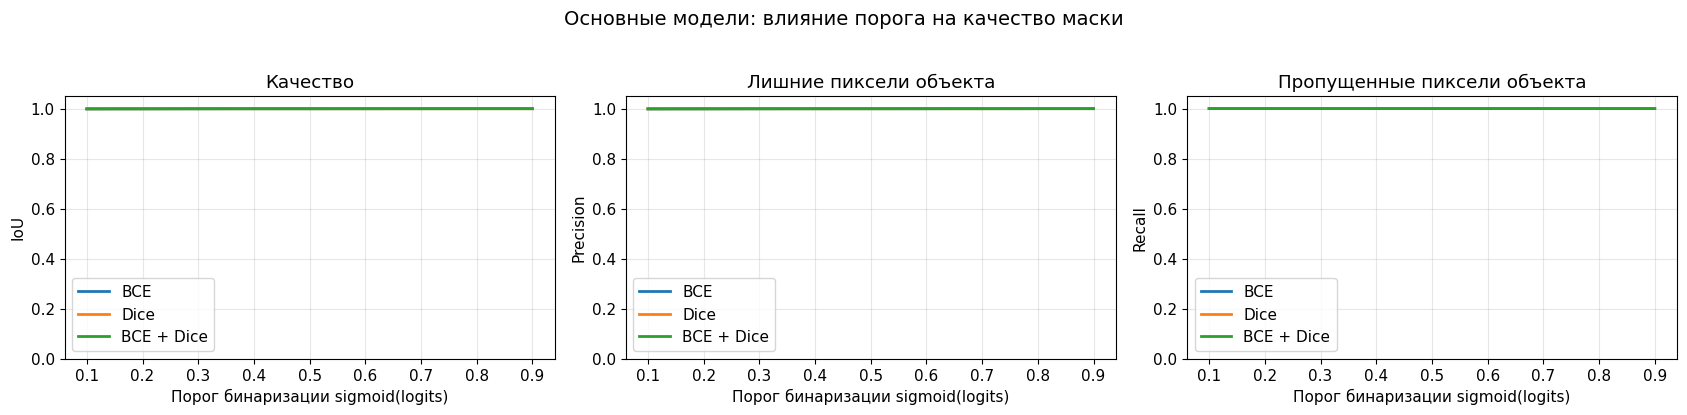

In [15]:
@torch.no_grad()
def threshold_sweep_binary_model(model, loader, thresholds=None, device=DEVICE, max_batches=None):
    """Показывает, как меняются IoU / precision / recall при разных threshold."""
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)

    rows = []
    for thr in thresholds:
        metrics = evaluate_binary_segmentation_model(
            model,
            loader,
            threshold=float(thr),
            device=device,
            max_batches=max_batches,
        )
        rows.append({"threshold": float(thr), **metrics})
    return rows


def plot_threshold_sweep_for_models(models, loader, thresholds=None, device=DEVICE, max_batches=None, title="Threshold sweep"):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    for name, model in models.items():
        rows = threshold_sweep_binary_model(
            model,
            loader,
            thresholds=thresholds,
            device=device,
            max_batches=max_batches,
        )
        thrs = [r["threshold"] for r in rows]
        axes[0].plot(thrs, [r["IoU"] for r in rows], linewidth=2, label=name)
        axes[1].plot(thrs, [r["Precision"] for r in rows], linewidth=2, label=name)
        axes[2].plot(thrs, [r["Recall"] for r in rows], linewidth=2, label=name)

    for ax, ylabel in zip(axes, ["IoU", "Precision", "Recall"]):
        ax.set_xlabel("Порог бинаризации sigmoid(logits)")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        ax.legend()

    axes[0].set_title("Качество")
    axes[1].set_title("Лишние пиксели объекта")
    axes[2].set_title("Пропущенные пиксели объекта")
    fig.suptitle(title, y=1.03, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_threshold_sweep_for_models(
    main_binary_models,
    val_loader,
    thresholds=np.linspace(0.1, 0.9, 17),
    title="Основные модели: влияние порога на качество маски",
)


# 9. Что нужно сдать

1. Реализованные классы и функции:
   - `DoubleConv`, `Down`, `Up`, `UNet`
   - `dice_loss`, `iou_score`
2. Графики:
   - кривая обучения первой модели (loss + val IoU),
   - сравнение трёх лоссов на одной картинке.
3. Визуализация предсказаний: 4 примера `(image, mask, prediction)`.
4. Краткий отчёт с ответами на вопросы из §11.
5. Дополнительные задания из §10: аугментации, сравнение глубины, мультикласс и focal loss.

# 10. Дополнительные задания (повышенной сложности)

1. **Аугментации.** Добавьте к датасету случайные повороты/отражения. Как это влияет на IoU?
2. **Глубина сети.** Сравните `UNet` глубины 3 и глубины 2 (без `down3`/`up1`). Какая модель учится быстрее, какая даёт лучший финальный IoU?
3. **Мульти-класс.** Расширьте датасет до 2 классов (круги + прямоугольники) и переделайте лосс на `CrossEntropyLoss`. Какие изменения нужны в архитектуре?
4. **Focal loss.** Реализуйте focal loss и сравните с Dice на сильно несбалансированных данных (мало объектов на изображении).

# 10.1 Доп. задание: общие настройки быстрых экспериментов

Дополнительные эксперименты ниже сделаны на меньшем датасете и с меньшим `base`, чтобы ноутбук можно было запустить на CPU за разумное время. Для более надёжных чисел увеличьте `EXTRA_EPOCHS`, `EXTRA_TRAIN_N`, `EXTRA_VAL_N` и `EXTRA_BASE`.


In [16]:
# Настройки дополнительных экспериментов.
# Для качества логика экспериментов полноценная: обучаются отдельные модели,
# строятся графики и выводятся финальные метрики. Чтобы ноутбук можно было
# запустить на CPU, датасет немного меньше основного.
# Финальный прогон: 50 эпох для дополнительных экспериментов. При нехватке времени можно временно уменьшить EXTRA_EPOCHS.
EXTRA_EPOCHS = 50
EXTRA_BATCH_SIZE = 32
EXTRA_BASE = 16
EXTRA_LR = 1e-3
EXTRA_TRAIN_N = 256
EXTRA_VAL_N = 96

extra_train_ds = SyntheticSegDataset(n_samples=EXTRA_TRAIN_N, seed=2024)
extra_val_ds = SyntheticSegDataset(n_samples=EXTRA_VAL_N, seed=2025)


def make_extra_loaders(train_dataset, val_dataset=extra_val_ds, batch_size=EXTRA_BATCH_SIZE, seed=2024):
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def plot_iou_histories(histories, title):
    plt.figure(figsize=(8, 4))
    for name, hist in histories.items():
        plt.plot(hist["val_iou"], linewidth=2, label=f"{name}: {hist['val_iou'][-1]:.3f}")
    plt.xlabel("Эпоха")
    plt.ylabel("val IoU")
    plt.ylim(0, 1.0)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def final_iou(history):
    return float(history["val_iou"][-1])


def total_train_time(history):
    return float(sum(history.get("epoch_time", [])))


# 10.2 Доп. задание 1 — аугментации

Добавим случайные отражения по горизонтали/вертикали и случайный поворот на `0`, `90`, `180` или `270` градусов. Для сегментации важно применять **одинаковое преобразование** и к изображению, и к маске.


[epoch  1] loss=1.4587  val_IoU=0.094  time=0.1s
[epoch  2] loss=1.3197  val_IoU=0.094  time=0.1s
[epoch  3] loss=1.2761  val_IoU=0.617  time=0.1s
[epoch  4] loss=1.2431  val_IoU=0.626  time=0.1s
[epoch  5] loss=1.2129  val_IoU=0.810  time=0.1s
[epoch  6] loss=1.1833  val_IoU=0.867  time=0.1s
[epoch  7] loss=1.1541  val_IoU=0.890  time=0.1s
[epoch  8] loss=1.1251  val_IoU=0.887  time=0.1s
[epoch  9] loss=1.0959  val_IoU=0.904  time=0.1s
[epoch 10] loss=1.0671  val_IoU=0.947  time=0.1s
[epoch 11] loss=1.0380  val_IoU=0.956  time=0.1s
[epoch 12] loss=1.0091  val_IoU=0.965  time=0.1s
[epoch 13] loss=0.9801  val_IoU=0.972  time=0.1s
[epoch 14] loss=0.9511  val_IoU=0.966  time=0.1s
[epoch 15] loss=0.9222  val_IoU=0.977  time=0.1s
[epoch 16] loss=0.8939  val_IoU=0.981  time=0.1s
[epoch 17] loss=0.8652  val_IoU=0.975  time=0.1s
[epoch 18] loss=0.8370  val_IoU=0.979  time=0.1s
[epoch 19] loss=0.8089  val_IoU=0.984  time=0.1s
[epoch 20] loss=0.7809  val_IoU=0.983  time=0.1s
[epoch 21] loss=0.75

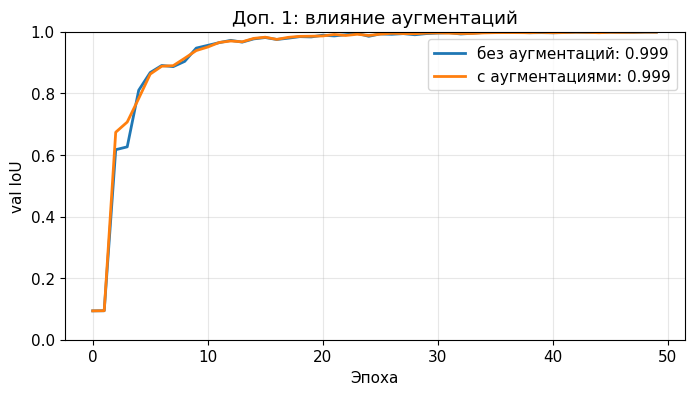

Финальный IoU без аугментаций: 0.999
Финальный IoU с аугментациями: 0.999


In [17]:
class AugmentedSegDataset(Dataset):
    """Обёртка над бинарным датасетом с простыми геометрическими аугментациями."""
    def __init__(self, base_dataset, p_hflip=0.5, p_vflip=0.5, random_rot90=True):
        self.base_dataset = base_dataset
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip
        self.random_rot90 = random_rot90

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, mask = self.base_dataset[idx]
        img = img.clone()
        mask = mask.clone()

        if self.random_rot90:
            k = torch.randint(0, 4, size=(1,)).item()
            img = torch.rot90(img, k=k, dims=(-2, -1))
            mask = torch.rot90(mask, k=k, dims=(-2, -1))

        if torch.rand(()) < self.p_hflip:
            img = torch.flip(img, dims=(-1,))
            mask = torch.flip(mask, dims=(-1,))

        if torch.rand(()) < self.p_vflip:
            img = torch.flip(img, dims=(-2,))
            mask = torch.flip(mask, dims=(-2,))

        return img, mask


aug_train_ds = AugmentedSegDataset(extra_train_ds)
plain_loader, extra_val_loader = make_extra_loaders(extra_train_ds, seed=11)
aug_loader, _ = make_extra_loaders(aug_train_ds, seed=11)

set_seed(11)
model_plain = UNet(base=EXTRA_BASE).to(DEVICE)
history_plain = train_unet(
    model_plain, plain_loader, extra_val_loader,
    loss_fn=combined_loss, epochs=EXTRA_EPOCHS, lr=EXTRA_LR,
)

set_seed(11)
model_aug = UNet(base=EXTRA_BASE).to(DEVICE)
history_aug = train_unet(
    model_aug, aug_loader, extra_val_loader,
    loss_fn=combined_loss, epochs=EXTRA_EPOCHS, lr=EXTRA_LR,
)

plot_iou_histories(
    {"без аугментаций": history_plain, "с аугментациями": history_aug},
    title="Доп. 1: влияние аугментаций",
)

print("Финальный IoU без аугментаций:", round(history_plain["val_iou"][-1], 3))
print("Финальный IoU с аугментациями:", round(history_aug["val_iou"][-1], 3))


**Вывод по аугментациям.** На маленьком синтетическом датасете аугментации могут дать небольшой выигрыш или почти не изменить метрику, потому что валидационные объекты уже генерируются в разных позициях. На реальных данных отражения и повороты обычно улучшают обобщение: модель видит больше вариантов расположения объекта и меньше переобучается на конкретные формы из train-набора.


# 10.3 Доп. задание 2 — глубина сети

Сравним исходную U-Net глубины 3 с более мелкой U-Net глубины 2, где убраны `down3` и `up1`. У мелкой модели меньше параметров и она быстрее учится, но у глубокой модели больше receptive field и потенциально лучше качество на сложных объектах.


[epoch  1] loss=1.2341  val_IoU=0.000  time=0.1s
[epoch  2] loss=1.0985  val_IoU=0.000  time=0.1s
[epoch  3] loss=1.0427  val_IoU=0.363  time=0.1s
[epoch  4] loss=0.9959  val_IoU=0.951  time=0.1s
[epoch  5] loss=0.9552  val_IoU=0.975  time=0.1s
[epoch  6] loss=0.9162  val_IoU=0.971  time=0.1s
[epoch  7] loss=0.8787  val_IoU=0.974  time=0.1s
[epoch  8] loss=0.8419  val_IoU=0.979  time=0.1s
[epoch  9] loss=0.8060  val_IoU=0.980  time=0.1s
[epoch 10] loss=0.7698  val_IoU=0.984  time=0.1s
[epoch 11] loss=0.7344  val_IoU=0.978  time=0.1s
[epoch 12] loss=0.7006  val_IoU=0.984  time=0.1s
[epoch 13] loss=0.6665  val_IoU=0.986  time=0.1s
[epoch 14] loss=0.6333  val_IoU=0.984  time=0.1s
[epoch 15] loss=0.6004  val_IoU=0.988  time=0.1s
[epoch 16] loss=0.5696  val_IoU=0.992  time=0.1s
[epoch 17] loss=0.5384  val_IoU=0.992  time=0.1s
[epoch 18] loss=0.5095  val_IoU=0.992  time=0.1s
[epoch 19] loss=0.4802  val_IoU=0.994  time=0.1s
[epoch 20] loss=0.4530  val_IoU=0.994  time=0.1s
[epoch 21] loss=0.42

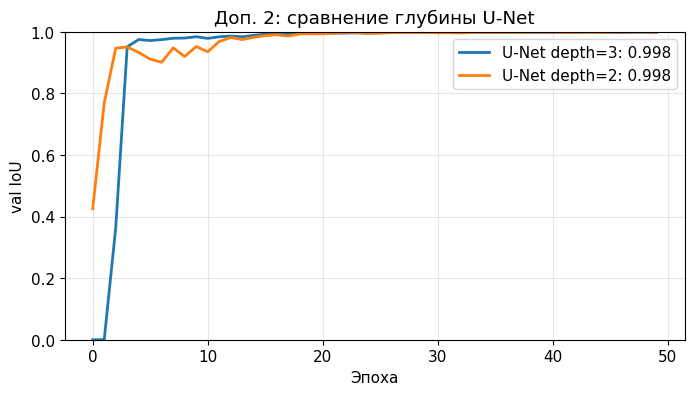

In [18]:
class UNetDepth2(nn.Module):
    """Более мелкая U-Net: два шага downsampling вместо трёх."""
    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)      # bottleneck
        self.up1 = Up(base * 4 + base * 2, base * 2)
        self.up2 = Up(base * 2 + base, base)
        self.outc = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.up1(x3, x2)
        x = self.up2(x, x1)
        return self.outc(x)


train_loader_depth, val_loader_depth = make_extra_loaders(extra_train_ds, seed=22)

set_seed(22)
model_depth3 = UNet(base=EXTRA_BASE).to(DEVICE)
history_depth3 = train_unet(
    model_depth3, train_loader_depth, val_loader_depth,
    loss_fn=combined_loss, epochs=EXTRA_EPOCHS, lr=EXTRA_LR,
)

train_loader_depth, val_loader_depth = make_extra_loaders(extra_train_ds, seed=22)

set_seed(22)
model_depth2 = UNetDepth2(base=EXTRA_BASE).to(DEVICE)
history_depth2 = train_unet(
    model_depth2, train_loader_depth, val_loader_depth,
    loss_fn=combined_loss, epochs=EXTRA_EPOCHS, lr=EXTRA_LR,
)

print(f"Параметры depth=3: {count_parameters(model_depth3):,}")
print(f"Параметры depth=2: {count_parameters(model_depth2):,}")
print(f"Время обучения depth=3: {total_train_time(history_depth3):.1f}s")
print(f"Время обучения depth=2: {total_train_time(history_depth2):.1f}s")

plot_iou_histories(
    {"U-Net depth=3": history_depth3, "U-Net depth=2": history_depth2},
    title="Доп. 2: сравнение глубины U-Net",
)


**Вывод по глубине сети.** `UNetDepth2` имеет заметно меньше параметров, поэтому одна эпоха обычно проходит быстрее. На простых 64×64 изображениях с кругами depth=2 часто достаточно. Depth=3 полезнее, когда объекты сложнее, требуется больший контекст или входные изображения крупнее.


# 10.4 Доп. задание 3 — мультикласс: круги + прямоугольники

Для мультиклассовой сегментации меняются три вещи:

1. маска хранит целочисленные классы `(H, W)`: `0` — фон, `1` — круг, `2` — прямоугольник;
2. последний слой модели выдаёт `out_channels=3` логита на пиксель;
3. вместо `BCEWithLogitsLoss` используется `CrossEntropyLoss`, который принимает logits формы `(B, C, H, W)` и target формы `(B, H, W)`.


Multi-class U-Net parameters: 487,747
[epoch  1] loss=0.9329  mean_val_IoU=0.031  time=0.1s
[epoch  2] loss=0.7189  mean_val_IoU=0.093  time=0.1s
[epoch  3] loss=0.6232  mean_val_IoU=0.181  time=0.1s
[epoch  4] loss=0.5558  mean_val_IoU=0.194  time=0.1s
[epoch  5] loss=0.5027  mean_val_IoU=0.358  time=0.1s
[epoch  6] loss=0.4555  mean_val_IoU=0.825  time=0.1s
[epoch  7] loss=0.4128  mean_val_IoU=0.913  time=0.1s
[epoch  8] loss=0.3744  mean_val_IoU=0.941  time=0.1s
[epoch  9] loss=0.3393  mean_val_IoU=0.937  time=0.1s
[epoch 10] loss=0.3077  mean_val_IoU=0.944  time=0.1s
[epoch 11] loss=0.2792  mean_val_IoU=0.945  time=0.1s
[epoch 12] loss=0.2537  mean_val_IoU=0.940  time=0.1s
[epoch 13] loss=0.2307  mean_val_IoU=0.969  time=0.1s
[epoch 14] loss=0.2105  mean_val_IoU=0.968  time=0.1s
[epoch 15] loss=0.1922  mean_val_IoU=0.975  time=0.1s
[epoch 16] loss=0.1753  mean_val_IoU=0.980  time=0.1s
[epoch 17] loss=0.1606  mean_val_IoU=0.979  time=0.1s
[epoch 18] loss=0.1477  mean_val_IoU=0.978  

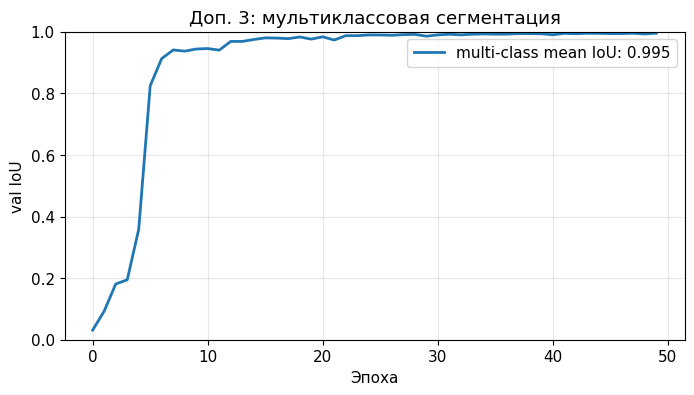

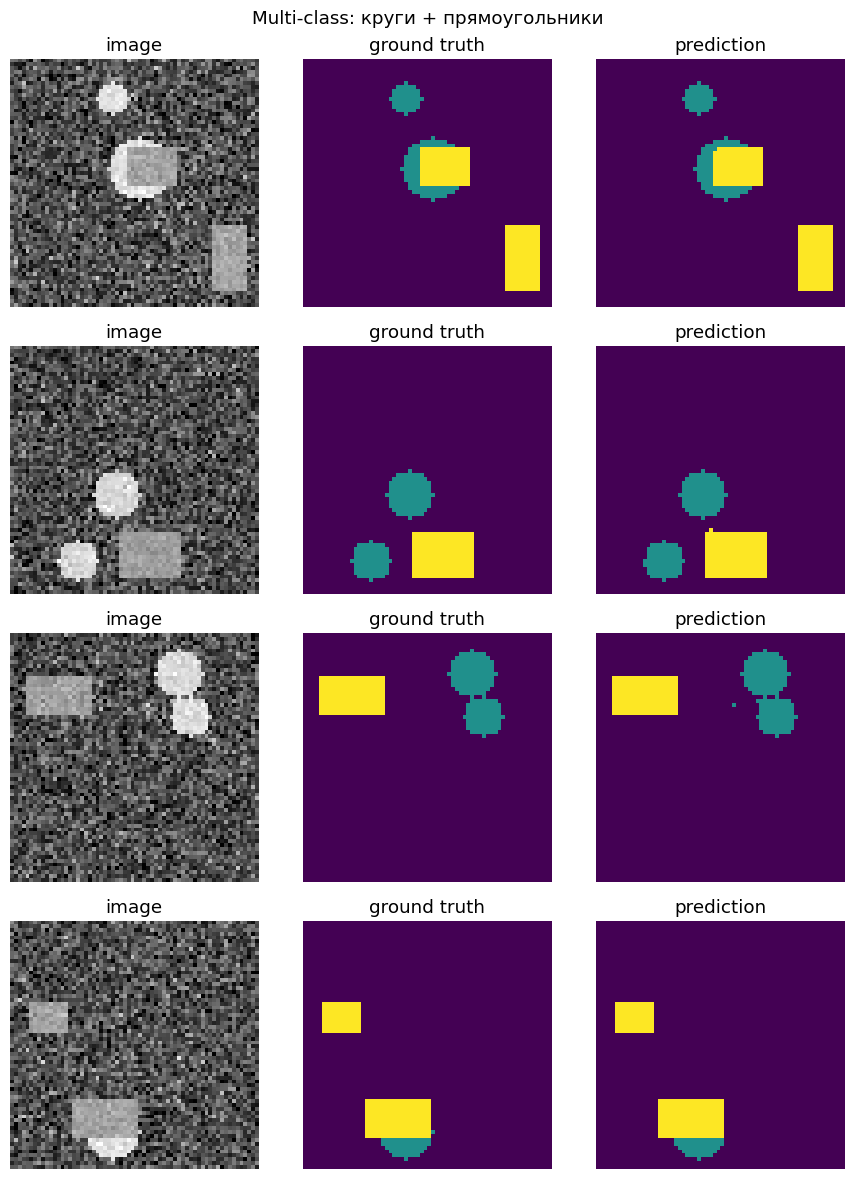

In [19]:
def _make_multiclass_sample(rng):
    img = rng.normal(loc=0.3, scale=0.15, size=(IMG_SIZE, IMG_SIZE)).astype(np.float32)
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.int64)
    yy, xx = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]

    # Класс 1: круги
    for _ in range(int(rng.integers(1, 3))):
        cx = rng.integers(8, IMG_SIZE - 8)
        cy = rng.integers(8, IMG_SIZE - 8)
        r = rng.integers(4, 11)
        circle = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        img[circle] = 0.85 + rng.normal(0, 0.05, size=circle.sum())
        mask[circle] = 1

    # Класс 2: прямоугольники
    for _ in range(int(rng.integers(1, 3))):
        w = rng.integers(7, 18)
        h = rng.integers(7, 18)
        x0 = rng.integers(2, IMG_SIZE - w - 2)
        y0 = rng.integers(2, IMG_SIZE - h - 2)
        rect = np.zeros_like(mask, dtype=bool)
        rect[y0:y0 + h, x0:x0 + w] = True
        img[rect] = 0.62 + rng.normal(0, 0.05, size=rect.sum())
        mask[rect] = 2

    img = np.clip(img, 0.0, 1.0)
    return img, mask


class MultiClassShapesDataset(Dataset):
    def __init__(self, n_samples=512, seed=0):
        self.n_samples = n_samples
        self.rng = np.random.default_rng(seed)
        self._cache = [_make_multiclass_sample(self.rng) for _ in range(n_samples)]

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img, mask = self._cache[idx]
        img_t = torch.from_numpy(img).unsqueeze(0)      # (1, H, W)
        mask_t = torch.from_numpy(mask).long()          # (H, W)
        return img_t, mask_t


def multiclass_iou_score(logits, target, num_classes=3, include_background=False, eps=1e-6):
    preds = logits.argmax(dim=1)  # (B, H, W)
    classes = range(num_classes) if include_background else range(1, num_classes)
    ious = []
    for cls in classes:
        pred_cls = preds == cls
        true_cls = target == cls
        intersection = (pred_cls & true_cls).sum(dim=(1, 2)).float()
        union = (pred_cls | true_cls).sum(dim=(1, 2)).float()
        ious.append(((intersection + eps) / (union + eps)).mean())
    return torch.stack(ious).mean()


def train_unet_multiclass(model, train_loader, val_loader, epochs=3, lr=1e-3, device=DEVICE):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_iou": [], "epoch_time": []}

    for epoch in range(epochs):
        start_time = time.perf_counter()
        model.train()
        epoch_loss = 0.0
        for imgs, masks in train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            logits = model(imgs)
            loss = loss_fn(logits, masks)

            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * imgs.size(0)

        epoch_loss /= len(train_loader.dataset)

        model.eval()
        ious = []
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device)
                masks = masks.to(device)
                logits = model(imgs)
                ious.append(multiclass_iou_score(logits, masks).item())

        val_iou = float(np.mean(ious))
        epoch_time = time.perf_counter() - start_time
        history["train_loss"].append(epoch_loss)
        history["val_iou"].append(val_iou)
        history["epoch_time"].append(epoch_time)
        print(
            f"[epoch {epoch + 1:2d}] loss={epoch_loss:.4f}  "
            f"mean_val_IoU={val_iou:.3f}  time={epoch_time:.1f}s"
        )

    return history


def show_multiclass_batch(images, masks, logits=None, n=4, title=""):
    n = min(n, images.shape[0])
    cols = 3 if logits is not None else 2
    fig, axes = plt.subplots(n, cols, figsize=(3 * cols, 3 * n))
    if n == 1:
        axes = axes[None, :]
    for i in range(n):
        axes[i, 0].imshow(images[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 0].set_title("image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(masks[i].cpu().numpy(), vmin=0, vmax=2)
        axes[i, 1].set_title("ground truth")
        axes[i, 1].axis("off")
        if logits is not None:
            pred = logits[i].argmax(dim=0).cpu().numpy()
            axes[i, 2].imshow(pred, vmin=0, vmax=2)
            axes[i, 2].set_title("prediction")
            axes[i, 2].axis("off")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()


mc_train_ds = MultiClassShapesDataset(n_samples=EXTRA_TRAIN_N, seed=31)
mc_val_ds = MultiClassShapesDataset(n_samples=EXTRA_VAL_N, seed=32)
mc_train_loader, mc_val_loader = make_extra_loaders(mc_train_ds, mc_val_ds, seed=33)

set_seed(33)
model_mc = UNet(out_channels=3, base=EXTRA_BASE).to(DEVICE)
print(f"Multi-class U-Net parameters: {count_parameters(model_mc):,}")
history_mc = train_unet_multiclass(
    model_mc, mc_train_loader, mc_val_loader,
    epochs=EXTRA_EPOCHS, lr=EXTRA_LR,
)

plot_iou_histories({"multi-class mean IoU": history_mc}, title="Доп. 3: мультиклассовая сегментация")

imgs_mc, masks_mc = next(iter(mc_val_loader))
imgs_mc = imgs_mc.to(DEVICE)
with torch.no_grad():
    logits_mc = model_mc(imgs_mc)
show_multiclass_batch(imgs_mc.cpu(), masks_mc, logits_mc.cpu(), n=4, title="Multi-class: круги + прямоугольники")


**Вывод по мультиклассу.** В архитектуре достаточно поменять `out_channels` с `1` на число классов (`3`: фон, круг, прямоугольник). Сигмоида больше не нужна: `CrossEntropyLoss` работает с многоклассовыми logits, а предсказание получается через `argmax` по каналам.


# 10.5 Доп. задание 4 — focal loss на несбалансированных данных

Сделаем более несбалансированный датасет: на изображении только один маленький объект. В такой ситуации фон занимает почти все пиксели, поэтому полезны Dice/Focal loss. Focal loss сильнее штрафует сложные пиксели и ослабляет вклад лёгких пикселей фона.


[epoch  1] loss=0.9714  val_IoU=0.000  time=0.1s
[epoch  2] loss=0.9663  val_IoU=0.099  time=0.1s
[epoch  3] loss=0.9634  val_IoU=0.680  time=0.1s
[epoch  4] loss=0.9600  val_IoU=0.026  time=0.1s
[epoch  5] loss=0.9547  val_IoU=0.320  time=0.1s
[epoch  6] loss=0.9437  val_IoU=0.020  time=0.1s
[epoch  7] loss=0.9282  val_IoU=0.011  time=0.1s
[epoch  8] loss=0.9183  val_IoU=0.069  time=0.1s
[epoch  9] loss=0.9048  val_IoU=0.012  time=0.1s
[epoch 10] loss=0.8865  val_IoU=0.269  time=0.1s
[epoch 11] loss=0.8705  val_IoU=0.217  time=0.1s
[epoch 12] loss=0.8518  val_IoU=0.418  time=0.1s
[epoch 13] loss=0.8354  val_IoU=0.910  time=0.1s
[epoch 14] loss=0.8202  val_IoU=0.178  time=0.1s
[epoch 15] loss=0.8149  val_IoU=0.811  time=0.1s
[epoch 16] loss=0.7946  val_IoU=0.169  time=0.1s
[epoch 17] loss=0.7562  val_IoU=0.081  time=0.1s
[epoch 18] loss=0.7582  val_IoU=0.246  time=0.1s
[epoch 19] loss=0.7322  val_IoU=0.294  time=0.1s
[epoch 20] loss=0.7178  val_IoU=0.174  time=0.1s
[epoch 21] loss=0.71

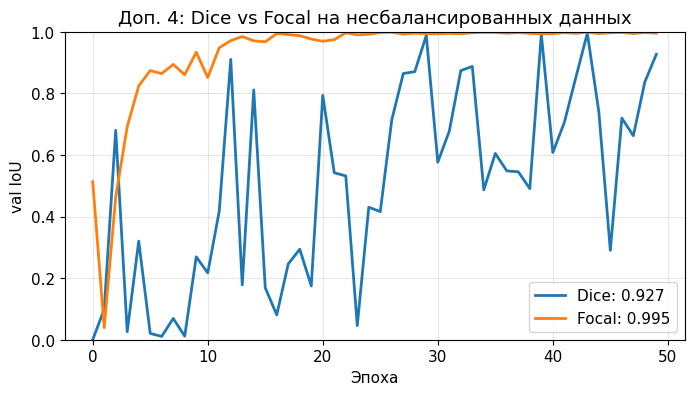

Финальный IoU Dice: 0.927
Финальный IoU Focal: 0.995


In [20]:
def _make_imbalanced_sample(rng):
    img = rng.normal(loc=0.3, scale=0.15, size=(IMG_SIZE, IMG_SIZE)).astype(np.float32)
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    yy, xx = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]

    cx = rng.integers(6, IMG_SIZE - 6)
    cy = rng.integers(6, IMG_SIZE - 6)
    r = rng.integers(2, 5)  # маленький объект => сильный дисбаланс фон/объект
    circle = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    img[circle] = 0.9 + rng.normal(0, 0.04, size=circle.sum())
    mask[circle] = 1.0
    img = np.clip(img, 0.0, 1.0)
    return img, mask


class ImbalancedCircleDataset(Dataset):
    def __init__(self, n_samples=512, seed=0):
        self.n_samples = n_samples
        self.rng = np.random.default_rng(seed)
        self._cache = [_make_imbalanced_sample(self.rng) for _ in range(n_samples)]

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img, mask = self._cache[idx]
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)


def binary_focal_loss_with_logits(logits, target, alpha=0.75, gamma=2.0, reduction="mean"):
    """Focal loss для бинарной сегментации.

    alpha > 0.5 увеличивает вес положительного класса, что полезно при редких объектах.
    gamma управляет тем, насколько сильно подавляются лёгкие примеры.
    """
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    probs = torch.sigmoid(logits)
    p_t = probs * target + (1.0 - probs) * (1.0 - target)
    alpha_t = alpha * target + (1.0 - alpha) * (1.0 - target)
    loss = alpha_t * (1.0 - p_t).pow(gamma) * bce

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    return loss


imb_train_ds = ImbalancedCircleDataset(n_samples=EXTRA_TRAIN_N, seed=41)
imb_val_ds = ImbalancedCircleDataset(n_samples=EXTRA_VAL_N, seed=42)
imb_train_loader, imb_val_loader = make_extra_loaders(imb_train_ds, imb_val_ds, seed=43)

set_seed(43)
model_imb_dice = UNet(base=EXTRA_BASE).to(DEVICE)
history_imb_dice = train_unet(
    model_imb_dice, imb_train_loader, imb_val_loader,
    loss_fn=dice_loss, epochs=EXTRA_EPOCHS, lr=EXTRA_LR,
)

imb_train_loader, imb_val_loader = make_extra_loaders(imb_train_ds, imb_val_ds, seed=43)

set_seed(43)
model_imb_focal = UNet(base=EXTRA_BASE).to(DEVICE)
history_imb_focal = train_unet(
    model_imb_focal, imb_train_loader, imb_val_loader,
    loss_fn=binary_focal_loss_with_logits, epochs=EXTRA_EPOCHS, lr=EXTRA_LR,
)

plot_iou_histories(
    {"Dice": history_imb_dice, "Focal": history_imb_focal},
    title="Доп. 4: Dice vs Focal на несбалансированных данных",
)

print("Финальный IoU Dice:", round(history_imb_dice["val_iou"][-1], 3))
print("Финальный IoU Focal:", round(history_imb_focal["val_iou"][-1], 3))


**Вывод по focal loss.** На сильно несбалансированных масках Dice обычно хорошо работает, потому что напрямую оптимизирует перекрытие маленького объекта. Focal loss полезен, когда много простых фоновых пикселей: он уменьшает их вклад и сильнее фокусирует обучение на редких/сложных пикселях объекта. На маленьком числе эпох результат может колебаться, поэтому для финального сравнения лучше запускать больше эпох и несколько seed.


## 10.5.1 Наглядная диагностика Dice vs Focal

Этот блок нужен именно для ситуации, когда на дисбалансированном датасете одна модель визуально «умирает». Вместо того чтобы спорить по raw loss, ниже смотрим на:

- IoU / Dice coefficient / precision / recall;
- долю пикселей, предсказанных объектом;
- probability-map и контуры предсказаний;
- худшие примеры Dice рядом с Focal на тех же изображениях;
- зависимость качества от порога бинаризации.

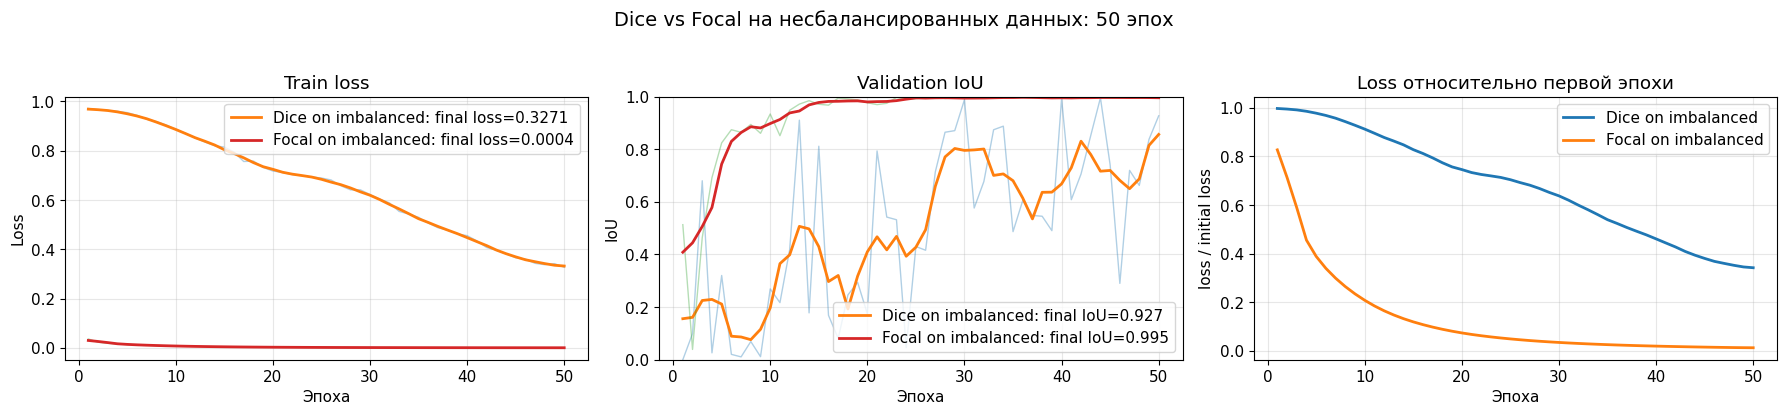

,model,IoU,Dice coefficient,Precision,Recall,Specificity,Predicted object pixels,True object pixels,Mean prob on object,Mean prob on background
0,Dice,0.9577,0.9784,0.9577,1.0,0.9997,0.0076,0.0073,0.9981,0.0809
1,Focal,0.9962,0.9981,0.9962,1.0,1.0000,0.0073,0.0073,0.9576,0.1180


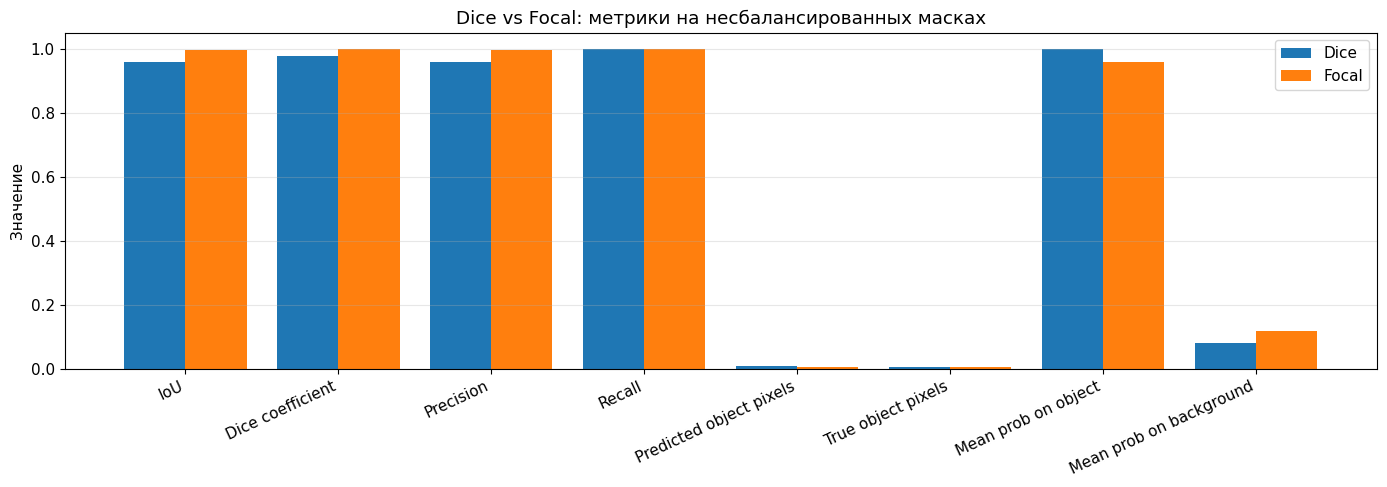

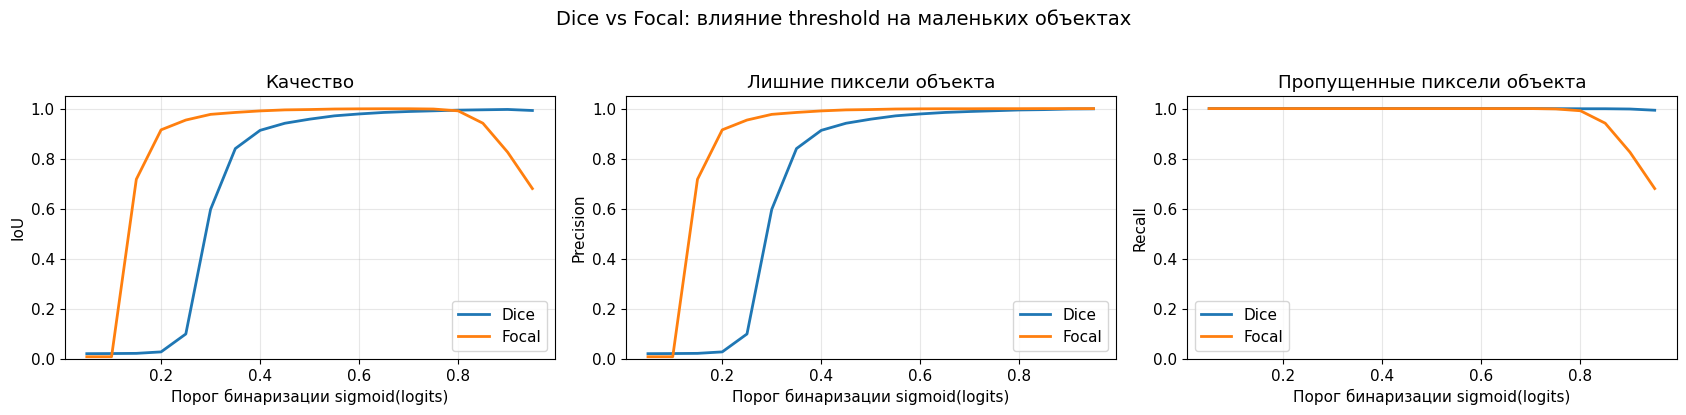

In [21]:
imbalanced_models = {
    "Dice": model_imb_dice,
    "Focal": model_imb_focal,
}

plot_segmentation_training_dashboard(
    {
        "Dice on imbalanced": history_imb_dice,
        "Focal on imbalanced": history_imb_focal,
    },
    smooth_window=5,
    title="Dice vs Focal на несбалансированных данных: 50 эпох",
)

imb_metrics = evaluate_binary_models(
    imbalanced_models,
    imb_val_loader,
    threshold=0.5,
)

plot_binary_model_metrics(
    imb_metrics,
    title="Dice vs Focal: метрики на несбалансированных масках",
)

plot_threshold_sweep_for_models(
    imbalanced_models,
    imb_val_loader,
    thresholds=np.linspace(0.05, 0.95, 19),
    title="Dice vs Focal: влияние threshold на маленьких объектах",
)


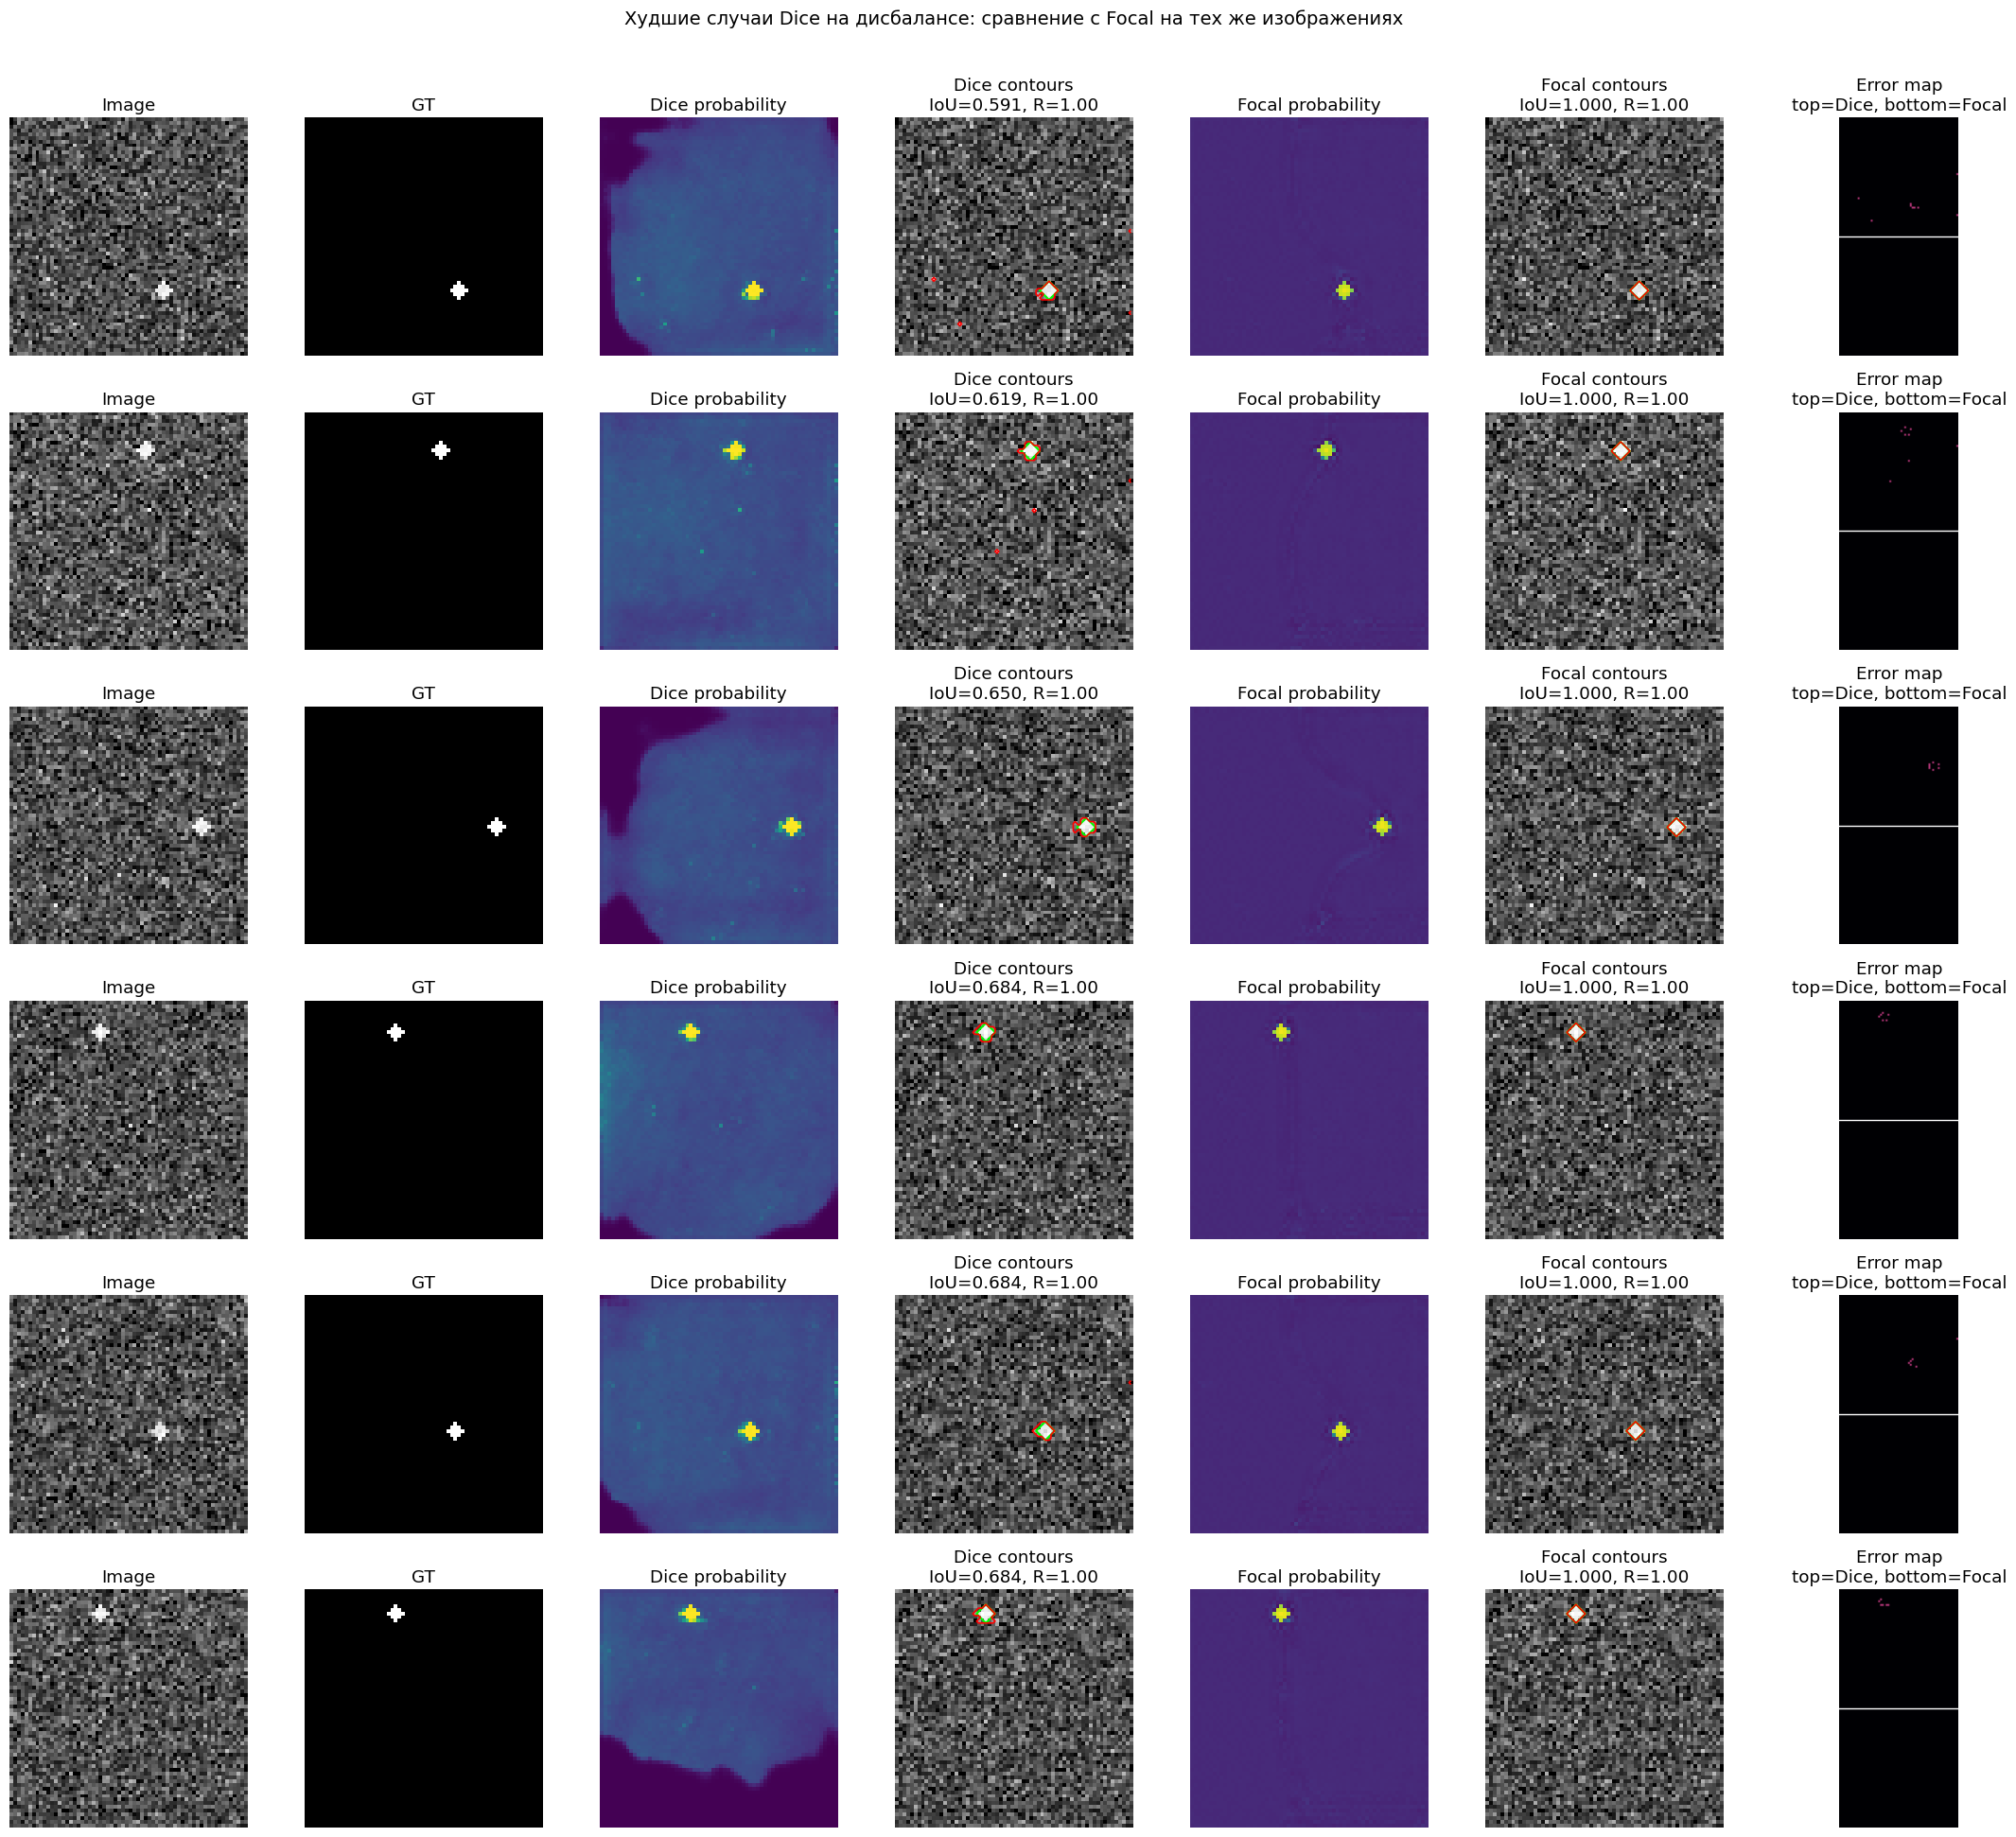

In [22]:
@torch.no_grad()
def show_dice_focal_failure_cases(
    dice_model,
    focal_model,
    loader,
    n=6,
    threshold=0.5,
    device=DEVICE,
    max_batches=6,
):
    """Показывает примеры, где Dice имеет минимальный IoU, а Focal сравнивается на тех же изображениях."""
    dice_samples = collect_segmentation_predictions(
        dice_model,
        loader,
        threshold=threshold,
        device=device,
        max_batches=max_batches,
    )

    # Берём индексы худших примеров Dice.
    worst_indices = np.argsort([s["iou"] for s in dice_samples])[:n]

    dice_model.eval()
    focal_model.eval()
    dice_model.to(device)
    focal_model.to(device)

    all_images = []
    all_masks = []
    for batch_idx, (images, masks) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        all_images.append(images)
        all_masks.append(masks)

    images_all = torch.cat(all_images, dim=0).to(device)
    masks_all = torch.cat(all_masks, dim=0).float().to(device)

    chosen_images = images_all[worst_indices]
    chosen_masks = masks_all[worst_indices]

    dice_probs = torch.sigmoid(dice_model(chosen_images)).detach().cpu().numpy()
    focal_probs = torch.sigmoid(focal_model(chosen_images)).detach().cpu().numpy()
    images_np = chosen_images[:, 0].detach().cpu().numpy()
    masks_np = chosen_masks[:, 0].detach().cpu().numpy()

    dice_preds = (dice_probs >= threshold).astype(float)
    focal_preds = (focal_probs >= threshold).astype(float)

    fig, axes = plt.subplots(n, 7, figsize=(22, 3.2 * n))
    if n == 1:
        axes = axes[None, :]

    for i in range(n):
        gt = masks_np[i]
        dice_prob = dice_probs[i, 0]
        focal_prob = focal_probs[i, 0]
        dice_pred = dice_preds[i, 0]
        focal_pred = focal_preds[i, 0]

        dice_m = _binary_metrics_np(dice_pred, gt)
        focal_m = _binary_metrics_np(focal_pred, gt)
        dice_err = _segmentation_error_map(dice_pred, gt)
        focal_err = _segmentation_error_map(focal_pred, gt)

        axes[i, 0].imshow(images_np[i], cmap="gray")
        axes[i, 0].set_title("Image")

        axes[i, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("GT")

        axes[i, 2].imshow(dice_prob, cmap="viridis", vmin=0, vmax=1)
        axes[i, 2].set_title("Dice probability")

        axes[i, 3].imshow(images_np[i], cmap="gray")
        axes[i, 3].contour(gt, levels=[0.5], colors="lime", linewidths=1.5)
        axes[i, 3].contour(dice_pred, levels=[0.5], colors="red", linewidths=1.2)
        axes[i, 3].set_title(f"Dice contours\nIoU={dice_m['iou']:.3f}, R={dice_m['recall']:.2f}")

        axes[i, 4].imshow(focal_prob, cmap="viridis", vmin=0, vmax=1)
        axes[i, 4].set_title("Focal probability")

        axes[i, 5].imshow(images_np[i], cmap="gray")
        axes[i, 5].contour(gt, levels=[0.5], colors="lime", linewidths=1.5)
        axes[i, 5].contour(focal_pred, levels=[0.5], colors="red", linewidths=1.2)
        axes[i, 5].set_title(f"Focal contours\nIoU={focal_m['iou']:.3f}, R={focal_m['recall']:.2f}")

        # В последнем столбце показываем разницу ошибок: сверху Dice, снизу Focal.
        combined_error = np.concatenate([dice_err, focal_err], axis=0)
        axes[i, 6].imshow(combined_error, cmap="magma", vmin=0, vmax=2)
        axes[i, 6].axhline(gt.shape[0] - 0.5, color="white", linewidth=1.0)
        axes[i, 6].set_title("Error map\ntop=Dice, bottom=Focal")

        for j in range(7):
            axes[i, j].axis("off")

    fig.suptitle(
        "Худшие случаи Dice на дисбалансе: сравнение с Focal на тех же изображениях",
        y=1.01,
        fontsize=14,
    )
    fig.tight_layout()
    plt.show()


show_dice_focal_failure_cases(
    model_imb_dice,
    model_imb_focal,
    imb_val_loader,
    n=6,
    threshold=0.5,
    max_batches=6,
)


In [23]:
def print_dice_focal_visual_conclusion(metrics_table):
    try:
        rows = {row["model"]: row for row in metrics_table.to_dict("records")}
    except AttributeError:
        rows = {row["model"]: row for row in metrics_table}

    dice = rows.get("Dice")
    focal = rows.get("Focal")
    if dice is None or focal is None:
        print("Не найдены строки Dice/Focal в таблице метрик")
        return

    print("Вывод по визуальной диагностике Dice vs Focal:")
    print(
        f"Dice:  IoU={dice['IoU']:.3f}, DiceCoef={dice['Dice coefficient']:.3f}, "
        f"Precision={dice['Precision']:.3f}, Recall={dice['Recall']:.3f}, "
        f"predicted object pixels={dice['Predicted object pixels']:.4f}"
    )
    print(
        f"Focal: IoU={focal['IoU']:.3f}, DiceCoef={focal['Dice coefficient']:.3f}, "
        f"Precision={focal['Precision']:.3f}, Recall={focal['Recall']:.3f}, "
        f"predicted object pixels={focal['Predicted object pixels']:.4f}"
    )
    print(
        "Raw loss у Dice и Focal напрямую сравнивать не стоит: у них разная форма и масштаб. "
        "Поэтому основной вывод делаем по IoU/Recall/Precision и по картинкам. "
        "Если Dice имеет низкий recall или почти нулевую долю predicted object pixels, "
        "это означает, что модель пропускает маленький объект. Если Focal при этом даёт выше IoU/Recall "
        "и визуально более точные контуры, значит Focal лучше справился с дисбалансом фон/объект."
    )


print_dice_focal_visual_conclusion(imb_metrics)


Вывод по визуальной диагностике Dice vs Focal:
Dice:  IoU=0.958, DiceCoef=0.978, Precision=0.958, Recall=1.000, predicted object pixels=0.0076
Focal: IoU=0.996, DiceCoef=0.998, Precision=0.996, Recall=1.000, predicted object pixels=0.0073
Raw loss у Dice и Focal напрямую сравнивать не стоит: у них разная форма и масштаб. Поэтому основной вывод делаем по IoU/Recall/Precision и по картинкам. Если Dice имеет низкий recall или почти нулевую долю predicted object pixels, это означает, что модель пропускает маленький объект. Если Focal при этом даёт выше IoU/Recall и визуально более точные контуры, значит Focal лучше справился с дисбалансом фон/объект.


# 10.6 Сводная таблица дополнительных экспериментов

Соберём финальные значения IoU, число параметров и время обучения в одну таблицу. Таблица нужна не только для красоты: по ней удобно делать выводы для отчёта.


In [24]:
extra_results = [
    {
        "experiment": "Augmentations: plain",
        "final_iou": final_iou(history_plain),
        "params": count_parameters(model_plain),
        "train_time_sec": total_train_time(history_plain),
    },
    {
        "experiment": "Augmentations: rot/flip",
        "final_iou": final_iou(history_aug),
        "params": count_parameters(model_aug),
        "train_time_sec": total_train_time(history_aug),
    },
    {
        "experiment": "Depth: U-Net depth=3",
        "final_iou": final_iou(history_depth3),
        "params": count_parameters(model_depth3),
        "train_time_sec": total_train_time(history_depth3),
    },
    {
        "experiment": "Depth: U-Net depth=2",
        "final_iou": final_iou(history_depth2),
        "params": count_parameters(model_depth2),
        "train_time_sec": total_train_time(history_depth2),
    },
    {
        "experiment": "Multi-class CE",
        "final_iou": final_iou(history_mc),
        "params": count_parameters(model_mc),
        "train_time_sec": total_train_time(history_mc),
    },
    {
        "experiment": "Imbalanced: Dice",
        "final_iou": final_iou(history_imb_dice),
        "params": count_parameters(model_imb_dice),
        "train_time_sec": total_train_time(history_imb_dice),
    },
    {
        "experiment": "Imbalanced: Focal",
        "final_iou": final_iou(history_imb_focal),
        "params": count_parameters(model_imb_focal),
        "train_time_sec": total_train_time(history_imb_focal),
    },
]

try:
    import pandas as pd
    results_df = pd.DataFrame(extra_results)
    results_df["final_iou"] = results_df["final_iou"].round(3)
    results_df["train_time_sec"] = results_df["train_time_sec"].round(1)
    display(results_df)
except Exception:
    for row in extra_results:
        print(
            f"{row['experiment']:<28} | "
            f"IoU={row['final_iou']:.3f} | "
            f"params={row['params']:,} | "
            f"time={row['train_time_sec']:.1f}s"
        )


,experiment,final_iou,params,train_time_sec
0,Augmentations: plain,0.999,487713,3.9
1,Augmentations: rot/flip,0.999,487713,4.0
2,Depth: U-Net depth=3,0.998,487713,3.7
3,Depth: U-Net depth=2,0.998,118305,2.7
4,Multi-class CE,0.995,487747,3.5
5,Imbalanced: Dice,0.927,487713,3.5
6,Imbalanced: Focal,0.995,487713,3.6


# 10.7 Итог по дополнительным заданиям

- **Аугментации** делают модель устойчивее к поворотам и отражениям. На простых синтетических кругах прирост может быть небольшим, потому что круги почти инвариантны к этим преобразованиям, но для реальных данных это обычно снижает переобучение.
- **Depth=2** обучается быстрее и имеет меньше параметров; **depth=3** даёт больший receptive field и обычно полезнее на более сложных изображениях или крупных объектах.
- **Мультикласс** требует `out_channels = num_classes`, маску типа `LongTensor` формы `(B, H, W)` и `CrossEntropyLoss`, который сам применяет `log_softmax` внутри.
- **Focal loss** полезен, когда положительный класс редкий: он уменьшает вклад лёгких фоновых пикселей и фокусирует градиент на сложных областях. Dice при этом остаётся сильным baseline, потому что напрямую оптимизирует перекрытие масок.


# 11. Вопросы для отчёта

1. Зачем в U-Net **skip-connections**? Что произойдёт с качеством сегментации, если их убрать?
2. Почему **Dice loss** часто лучше BCE на задачах с сильным дисбалансом классов?
3. Почему модель выдаёт **логиты** (без сигмоиды), а сигмоида применяется только в лоссе/метрике?
4. Чем отличается `IoU` от `Dice coefficient`? Связаны ли они формулой?
5. Что произойдёт, если в `BatchNorm2d` подавать батч размера 1? Когда BN можно безопасно заменить на `GroupNorm` или `InstanceNorm`?

# 12. Ответы на вопросы для отчёта

**1. Зачем в U-Net skip-connections? Что будет, если их убрать?**  
Skip-connections передают в декодер признаки высокого разрешения из энкодера. Благодаря этому модель лучше восстанавливает мелкие детали и границы объектов. Если убрать skip-connections, декодер будет восстанавливать маску только из сжатого bottleneck-представления: границы станут более размытыми, мелкие объекты и тонкие детали будут теряться, IoU обычно снизится.

**2. Почему Dice loss часто лучше BCE при сильном дисбалансе классов?**  
В сегментации фон обычно занимает намного больше пикселей, чем объект. BCE усредняется по пикселям, поэтому модель может получить небольшой loss, хорошо предсказывая фон, но плохо выделяя объект. Dice loss оптимизирует перекрытие предсказанной и истинной маски, поэтому сильнее фокусируется на качестве сегментации объекта.

**3. Почему модель выдаёт логиты, а сигмоида применяется только в loss/metric?**  
`BCEWithLogitsLoss` внутри объединяет sigmoid и BCE в численно устойчивой форме. Если заранее применять sigmoid и затем считать BCE, можно получить проблемы с очень маленькими/большими вероятностями и менее стабильные градиенты. Для метрик sigmoid нужна только на этапе интерпретации logits как вероятностей.

**4. Чем отличается IoU от Dice coefficient? Связаны ли они формулой?**  
Обе метрики измеряют перекрытие масок.  
IoU:
\[
IoU = \frac{|A \cap B|}{|A \cup B|}
\]
Dice:
\[
Dice = \frac{2|A \cap B|}{|A| + |B|}
\]
Они связаны формулами:
\[
Dice = \frac{2IoU}{1 + IoU}, \qquad IoU = \frac{Dice}{2 - Dice}.
\]
Dice обычно численно больше IoU при том же качестве предсказания.

**5. Что будет, если в BatchNorm2d подавать batch size = 1? Когда заменить на GroupNorm или InstanceNorm?**  
При batch size = 1 статистики BatchNorm оцениваются плохо: среднее и дисперсия по батчу становятся шумными, обучение может быть нестабильным. В режиме `eval()` BatchNorm использует накопленные running statistics, но во время обучения маленький batch всё равно может мешать. Если из-за памяти приходится обучать с batch size 1–2, часто лучше заменить BatchNorm на `GroupNorm` или `InstanceNorm`, потому что они не зависят от статистики по батчу.